# Pixel-Based Deep Reinforcement Learning for Vision-Based Robotic Grasping in MuJoCo

**A reproducible online RL experiment • Franka Panda • pixels → CNN → continuous control**

Research question: can a manipulator learn reliable grasping from RGB and robot proprioception, without object pose in its policy input?
This notebook implements online Pixel SAC (primary), online Pixel PPO, and a clearly labeled privileged-state SAC baseline.
All visual encoders start randomly initialized. There are no demonstrations, detectors, datasets, pretrained weights, or API keys.

**Run:** select a GPU Colab runtime when available, set `MODE` below, then Run all. Start with SMOKE.
SMOKE verifies software, not learning. STANDARD targets 60 minutes including setup and reserves a 90-minute cooperative safety ceiling.
FULL runs three seeds and four controlled ablations, with two million steps per run; it is intentionally a multi-session experiment.
Runtime budgets are estimates, not hardware guarantees. No notebook can preempt a blocked driver, installation, or filesystem call.

## Revision 2: address the failed run's training starvation
The previous STANDARD run completed in 40.92 minutes but trained Pixel SAC for only 164 seconds and PPO for zero updates.
This revision protects minimum training exposure, finishes PPO rollouts, budgets fewer scheduled validation episodes,
and starts the open gripper 14 cm above the table at a fixed location independent of object position.
It also strengthens progress shaping and physical grip control and lowers SAC's initial entropy coefficient.
These changes improve the conditions for learning; they are not evidence of learned grasping until this revision is trained.
Success still requires a physical bilateral grasp, a 10 cm lift, and a 0.5-second stable hold. No demonstrations or object-aware
controller are introduced. New evaluation seeds and a new experiment directory keep v1 results separate.
STANDARD protects 12,000 Pixel SAC / 2,048 PPO / 4,096 State SAC online steps as minimums, not convergence guarantees.
If calibration cannot fit those floors plus evaluation inside the safety ceiling, it reports infeasibility instead of
silently selecting untrained models. FULL retains the larger multi-session research design.

## Method and experimental contract
At 20 Hz, the policy commands Cartesian translation, yaw, and continuous gripper aperture. A damped least-squares IK controller
drives the seven physical Panda joints; MuJoCo integrates contacts at 500 Hz. A success requires bilateral contact, a secure grasp,
at least 10 cm vertical displacement from the settled object center, and a continuous 0.5-second hold.

Training episodes are generated online. Validation and test are fixed **environment configuration banks**, not a supervised dataset split.
Validation alone selects checkpoints. Test access follows an immutable selection manifest. FULL aggregates every seed, including failures.
A low success rate is an experimental finding, not a reason to replace results.


In [1]:
import os, sys, time, subprocess, platform
NOTEBOOK_START = time.monotonic()
MODE = "STANDARD"                  # "SMOKE", "STANDARD", or "FULL"
USE_DRIVE = False                  # Optional; authentication is only for your own Drive
EXPERIMENT_NAME = "panda_pixels_v2" # New namespace; never reuse v1 checkpoints or frozen selections
RESUME = True
PERSIST_REPLAY = False             # True can create multi-GB checkpoints; local storage recommended
FULL_SESSION_HOURS = 4.0           # Session slice, NOT a reduction of FULL's step budgets
assert MODE in {"SMOKE", "STANDARD", "FULL"}


## Colab setup and dependencies
Pin the physics and RL APIs. Keep Colab's CUDA-enabled PyTorch when it is already installed; record its exact version.
EGL is selected before importing MuJoCo on GPU Linux; CPU Linux uses OSMesa. Windows uses GLFW for local verification.
Installation and asset download require internet access, but no account or secret.


In [2]:
INSTALL_STARTED=time.monotonic()
if platform.system() == "Linux":
    has_gpu = subprocess.run(["bash", "-lc", "command -v nvidia-smi >/dev/null && nvidia-smi -L"],
                             capture_output=True).returncode == 0
    os.environ["MUJOCO_GL"] = "egl" if has_gpu else "osmesa"
    if not has_gpu:
        subprocess.run(["apt-get", "-qq", "update"], check=True, timeout=180)
        subprocess.run(["apt-get", "-qq", "install", "-y", "libosmesa6"], check=True, timeout=180)
subprocess.run([sys.executable, "-m", "pip", "-q", "install",
    "mujoco==3.3.5", "gymnasium==1.2.0", "stable-baselines3==2.7.0",
    "numpy>=1.26,<3", "pandas>=2.2,<4", "matplotlib>=3.8,<4", "psutil>=5.9",
    "imageio==2.37.0", "imageio-ffmpeg==0.6.0", "pillow>=10", "scipy>=1.12"], check=True, timeout=600)

INSTALL_SECONDS=time.monotonic()-INSTALL_STARTED


In [3]:
IMPORT_STARTED=time.monotonic()
import copy, gc, hashlib, json, math, random, shutil, warnings
import xml.etree.ElementTree as ET
from collections import deque
from dataclasses import dataclass, asdict, field
from pathlib import Path
from importlib.metadata import version
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil, torch, mujoco, gymnasium as gym
from torch import nn
from gymnasium import spaces
from scipy.spatial.transform import Rotation
from PIL import Image, ImageDraw
import imageio.v2 as imageio
from IPython.display import display, Markdown, Video
from stable_baselines3 import SAC, PPO
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.logger import configure
from stable_baselines3.common.env_checker import check_env
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_num_threads(min(4, os.cpu_count() or 1))
print("Device:", DEVICE, "PyTorch:", torch.__version__, "MuJoCo:", mujoco.__version__)

IMPORT_SECONDS=time.monotonic()-IMPORT_STARTED


Device: cuda PyTorch: 2.11.0+cu128 MuJoCo: 3.3.5


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Configuration, reproducibility, and storage
Every quantity affecting the task is centralized here. Joint positions are divided by π, velocities clipped/scaled by 5 rad/s,
and the two physical finger positions by 4 cm. These are fixed transforms: there are no fitted observation statistics to leak
between splits. The controller target is internal state and is not given to the policy.

STANDARD uses one training seed and 12 validation / 24 test configurations. These small banks have appreciable uncertainty.
FULL uses 100 validation / 300 test configurations per run and 80 per shifted condition. Three seeds are independent algorithm
initializations and training streams; all agents share evaluation configurations for paired comparisons.


In [4]:
@dataclass
class PhysicsConfig:
    timestep: float = 0.002
    control_steps: int = 25
    horizon: int = 200
    image_size: int = 84
    render_samples: int = 0
    render_shadows: bool = False
    translation: float = 0.02
    yaw_increment: float = 0.12
    workspace_low: tuple = (0.28, -0.24, 0.025)
    workspace_high: tuple = (0.68, 0.24, 0.50)
    home: tuple = (0.0, -0.4, 0.0, -2.2, 0.0, 1.8, 0.785398)
    initial_ee: tuple = (0.48, 0.0, 0.14)
    reset_ik_passes: int = 3
    gripper_stiffness: float = 400.0
    gripper_damping: float = 20.0
    lift_height: float = 0.10
    secure_seconds: float = 0.10
    hold_seconds: float = 0.50
    max_relative_speed: float = 0.25
    max_grasp_distance: float = 0.06
    min_contact_force: float = 0.05
    collision_force: float = 8.0
    ik_damping: float = 0.04
    ik_iterations: int = 8
    ik_joint_increment: float = 0.10

@dataclass
class RewardConfig:
    approach: float = 10.0
    closure_progress: float = 1.0
    closure_radius: float = 0.035
    contact: float = 1.0
    grasp: float = 2.0
    lift_progress: float = 20.0
    lift: float = 5.0
    success: float = 10.0
    collision: float = 2.0
    action: float = 0.002
    drop: float = 3.0

@dataclass
class RandomizationConfig:
    xy_halfwidths: tuple = (0.018, 0.05, 0.08, 0.12)
    yaw_scales: tuple = (0.25, 0.5, 0.75, 1.0)
    yaw: float = 0.65
    joint_jitter: float = 0.025
    halfsize: tuple = (0.018, 0.024)
    mass: tuple = (0.06, 0.12)
    friction: tuple = (0.8, 1.2)
    camera_translation: float = 0.012
    camera_rotation: float = 0.025
    light_intensity: tuple = (0.7, 1.0)

@dataclass
class ExperimentConfig:
    mode: str = MODE
    seeds: tuple = (11, 29, 47) if MODE == "FULL" else (11,)
    validation_n: int = {"SMOKE": 1, "STANDARD": 12, "FULL": 100}[MODE]
    test_n: int = {"SMOKE": 1, "STANDARD": 24, "FULL": 300}[MODE]
    shift_n: int = {"SMOKE": 1, "STANDARD": 6, "FULL": 80}[MODE]
    levels: tuple = tuple(range(1, 8)) if MODE == "FULL" else (1, 3, 5)
    learning_rate: float = 3e-4
    gamma: float = 0.99
    batch_size: int = 128 if DEVICE == "cuda" else 64
    tau: float = 0.005
    learning_starts: int = 32 if MODE == "SMOKE" else 512
    train_freq: int = 2
    initial_entropy: float = 0.1
    gradient_steps: int = 1
    ppo_rollout: int = 64 if MODE=="SMOKE" else 256
    ppo_epochs: int = 5
    full_steps: int = 2_000_000
    checkpoint_steps: int = 2048
    validation_steps: int = 20_000
    stable_threshold: float = 0.85
    early_window: int = 3
    target_seconds: float = 3600
    hard_seconds: float = 5400
    minimum_steps: tuple = (12000, 2048, 4096)
    standard_validation_checks: int = 3

PHYS, REWARD, RAND, CFG = PhysicsConfig(), RewardConfig(), RandomizationConfig(), ExperimentConfig()
def seed_everything(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True, warn_only=True)

def json_default(value):
    if isinstance(value, (np.integer, np.floating, np.bool_)): return value.item()
    if isinstance(value, np.ndarray): return value.tolist()
    if isinstance(value, Path): return str(value)
    raise TypeError(type(value).__name__)

def write_json(path, obj):
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_text(json.dumps(obj, indent=2, default=json_default), encoding="utf-8")
    os.replace(tmp, path)

def read_json(path, default=None):
    return json.loads(Path(path).read_text()) if Path(path).exists() else copy.deepcopy(default)

if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    STORAGE = Path("/content/drive/MyDrive")
else:
    STORAGE = Path("/content") if Path("/content").exists() else Path.cwd() / "runs"
ROOT = STORAGE / EXPERIMENT_NAME / MODE.lower()
for directory in ("checkpoints", "logs", "figures", "videos", "configs", "evaluation", "results"):
    (ROOT / directory).mkdir(parents=True, exist_ok=True)
config_record = {"experiment": asdict(CFG), "physics": asdict(PHYS), "reward": asdict(REWARD),
                 "randomization": asdict(RAND), "device": DEVICE, "persist_replay": PERSIST_REPLAY}
existing_config = read_json(ROOT / "configs/config.json")
if existing_config and RESUME:
    # Retain the original optimization batch size even if Colab assigns a different device on resume.
    CFG.batch_size=existing_config["experiment"]["batch_size"]
    config_record["experiment"]=asdict(CFG)
    for key in ("physics", "reward", "randomization", "experiment"):
        assert existing_config[key] == json.loads(json.dumps(config_record[key])), "Config changed: use a new experiment name"
write_json(ROOT / "configs/config.json", config_record)
write_json(ROOT / "configs/versions.json", {p: version(p) for p in
    ["torch", "numpy", "mujoco", "gymnasium", "stable-baselines3", "pandas", "imageio"]})
seed_everything(CFG.seeds[0])
print("Artifacts:", ROOT)


Artifacts: /content/panda_pixels_v2/standard


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Open Panda assets and camera
The Apache-2.0 [MuJoCo Menagerie Panda](https://github.com/google-deepmind/mujoco_menagerie/tree/main/franka_emika_panda)
supplies physical inertias, collision meshes, and the coupled parallel gripper. A commit is pinned and logged.
We add the tabletop, task object, camera, and fingertip-center site. Original geometry attribution/license remain with the assets.
No object is welded to the robot, and no force is applied directly to the object.


In [5]:
ASSET_COMMIT = "822c2d8f877dd166c5b7d3c9f7e3c3b6589473b7"
ASSET_STARTED=time.monotonic()
ASSET_DIR = Path("/content/panda_menagerie") if Path("/content").exists() else Path.cwd() / "menagerie"
if not (ASSET_DIR / ".git").exists():
    subprocess.run(["git", "clone", "--filter=blob:none", "--no-checkout",
                    "https://github.com/google-deepmind/mujoco_menagerie.git", str(ASSET_DIR)], check=True, timeout=240)
subprocess.run(["git", "-C", str(ASSET_DIR), "sparse-checkout", "set", "franka_emika_panda"], check=True, timeout=240)
subprocess.run(["git", "-C", str(ASSET_DIR), "checkout", ASSET_COMMIT], check=True, timeout=240)
PANDA_DIR = ASSET_DIR / "franka_emika_panda"
write_json(ROOT / "configs/assets.json", {"repository": "google-deepmind/mujoco_menagerie", "commit": ASSET_COMMIT})

def camera_quaternion(position, target):
    z = np.asarray(position) - target; z /= np.linalg.norm(z)
    x = np.cross([0., 0., 1.], z); x /= np.linalg.norm(x)
    y = np.cross(z, x)
    xyzw = Rotation.from_matrix(np.column_stack([x, y, z])).as_quat()
    return np.roll(xyzw, 1)

def scene_xml():
    root = ET.parse(PANDA_DIR / "panda.xml").getroot()
    root.find("compiler").set("meshdir", str((PANDA_DIR / "assets").resolve()))
    root.find("option").set("timestep", str(PHYS.timestep))
    root.find("option").set("gravity", "0 0 -9.81")
    root.remove(root.find("keyframe"))
    finger_actuator=root.find(".//actuator/general[@name='actuator8']")
    finger_actuator.set("gainprm",f"{PHYS.gripper_stiffness*.04/255} 0 0")
    finger_actuator.set("biasprm",f"0 {-PHYS.gripper_stiffness} {-PHYS.gripper_damping}")
    ET.SubElement(root, "visual")
    ET.SubElement(root.find("visual"), "global", offwidth="640", offheight="480")
    ET.SubElement(root.find("visual"), "quality", offsamples=str(PHYS.render_samples), shadowsize="1024")
    world = root.find("worldbody")
    for light in list(world.findall("light")): world.remove(light)
    ET.SubElement(world, "light", name="task_light", pos="0.2 -0.3 1.4", dir="0.2 0.2 -1", diffuse="0.9 0.9 0.9")
    ET.SubElement(world, "geom", name="table", type="box", size="0.65 0.55 0.025", pos="0.35 0 -0.025",
                  rgba="0.45 0.42 0.36 1", friction="1 0.005 0.0001")
    obj = ET.SubElement(world, "body", name="object", pos="0.48 0 0.022")
    ET.SubElement(obj, "freejoint", name="object_joint")
    ET.SubElement(obj, "geom", name="object_geom", type="box", size="0.022 0.022 0.022", mass="0.08",
                  rgba="0.8 0.12 0.1 1", friction="1 0.005 0.0001", condim="4", solref="0.01 1")
    hand = root.find(".//body[@name='hand']")
    ET.SubElement(hand, "site", name="grasp_center", pos="0 0 0.1034", size="0.002", rgba="0 0 0 0")
    pos = np.array([1.05, -0.85, 0.85])
    ET.SubElement(world, "camera", name="external", pos=" ".join(map(str, pos)),
                  quat=" ".join(map(str, camera_quaternion(pos, np.array([0.43, 0., 0.15])))), fovy="48")
    return ET.tostring(root, encoding="unicode")
SCENE_XML = scene_xml()
(ROOT / "configs/scene.xml").write_text(SCENE_XML,encoding="utf-8")
ASSET_SECONDS=time.monotonic()-ASSET_STARTED


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Randomization and disjoint configuration banks
Training randomization grows with curriculum stages. Evaluation always uses the final task, fixed full-distribution settings,
and no curriculum shortcuts. Even the no-randomization ablation trains over a nominal position/yaw distribution; it removes
nuisance visual/physical randomization only. Other ablations change exactly one flag.

Shift levels are **separate stress tests**, not a calibrated monotonic difficulty scale. Positions, yaw, appearance,
lighting, camera, size, and geometry move outside training support in turn. All seven run in FULL.


In [6]:
def episode_config(seed, stage=3, randomize=True, level=0):
    rng = np.random.default_rng(int(seed))
    width = RAND.xy_halfwidths[stage]
    xy = np.array([0.48, 0.0]) + rng.uniform(-width, width, 2)
    nuisance = randomize and stage >= 2
    size = rng.uniform(*RAND.halfsize, 3) if nuisance else np.full(3, 0.022)
    c = dict(seed=int(seed), xy=xy.tolist(), yaw=float(rng.uniform(-RAND.yaw, RAND.yaw)*RAND.yaw_scales[stage]),
             halfsize=size.tolist(), geometry="box", mass=float(rng.uniform(*RAND.mass)) if nuisance else 0.08,
             friction=float(rng.uniform(*RAND.friction)) if nuisance else 1.0,
             color=rng.uniform([0.5, 0.08, 0.05], [0.95, 0.4, 0.3]).tolist() if nuisance else [0.8, 0.12, 0.1],
             table=rng.uniform(0.3, 0.6, 3).tolist() if nuisance else [0.45, 0.42, 0.36],
             light=float(rng.uniform(*RAND.light_intensity)) if nuisance else 0.9,
             light_dir=(np.array([0.2, 0.2, -1]) + rng.uniform(-0.1, 0.1, 3)).tolist() if nuisance else [0.2, 0.2, -1],
             camera_delta=rng.uniform(-RAND.camera_translation, RAND.camera_translation, 3).tolist() if nuisance else [0., 0., 0.],
             camera_rot=rng.uniform(-RAND.camera_rotation, RAND.camera_rotation, 3).tolist() if nuisance else [0., 0., 0.],
             joint_delta=rng.uniform(-RAND.joint_jitter, RAND.joint_jitter, 7).tolist() if randomize else [0.] * 7,
             level=int(level))
    if level == 1:
        axis = int(rng.integers(2)); c["xy"][axis] = [0.48, 0][axis] + rng.choice([-1, 1]) * rng.uniform(0.135, 0.16)
    elif level == 2: c["yaw"] = float(rng.choice([-1, 1]) * rng.uniform(0.9, 1.5))
    elif level == 3: c.update(color=[0.08, float(rng.uniform(0.5, 0.95)), 0.95], table=[0.15, 0.2, 0.25])
    elif level == 4: c.update(light=0.4, light_dir=[-0.6, 0.8, -0.5])
    elif level == 5:
        c.update(camera_delta=[0.07, -0.06, 0.04], camera_rot=[0.06, -0.07, 0.04])
    elif level == 6: c["halfsize"] = [0.028, 0.014, 0.03]
    elif level == 7:
        c["geometry"] = str(rng.choice(["sphere", "cylinder", "capsule"]))
        c["halfsize"] = [0.02, 0.02, 0.02]
    return c

def configuration_banks(cfg):
    banks = {"validation": [episode_config(10_000_000+i) for i in range(cfg.validation_n)],
             "test": [episode_config(20_000_000+i) for i in range(cfg.test_n)]}
    for level in cfg.levels:
        banks[f"shift_{level}"] = [episode_config(30_000_000+level*10_000+i, level=level) for i in range(cfg.shift_n)]
    seeds = [c["seed"] for bank in banks.values() for c in bank]
    assert len(seeds) == len(set(seeds))
    return banks

# Training uses episode seeds >= 100 million, never a validation/test/shift seed.
@dataclass
class AgentSpec:
    name: str
    algo: str = "SAC"
    pixels: bool = True
    proprio: bool = True
    randomization: bool = True
    shaped: bool = True
    curriculum: bool = True

MAIN_SPECS = [AgentSpec("Pixel SAC"), AgentSpec("Pixel PPO", algo="PPO"), AgentSpec("State SAC", pixels=False)]
ABLATIONS = [AgentSpec("Pixel SAC no randomization", randomization=False),
             AgentSpec("Pixel SAC RGB only", proprio=False), AgentSpec("Pixel SAC sparse", shaped=False),
             AgentSpec("Pixel SAC no curriculum", curriculum=False)]


## Physical environment, controller, observation firewall, and rewards
Actions are clipped to [-1,1]. The first three channels move a bounded end-effector target by up to 2 cm;
yaw changes by up to 0.12 radians. The last channel sets aperture continuously (−1 closed, +1 open).
IK uses only robot kinematics and the commanded target, never the object pose. Joint-position actuators and gravity compensation
act on the arm; the coupled tendon actuator controls the fingers with stiffness 400 and damping 20.
Reset-only IK uses a fixed workspace target (0.48, 0, 0.14 m), then adds robot jitter; it never targets the sampled object.

`pixel_observation()` explicitly constructs an allowlist: RGB and robot joints/fingers only. Privileged diagnostics live exclusively
in `info`, which SB3 does not concatenate to observations. State SAC has a separate observation space.

Approach uses 10× distance progress. Closure shaping rewards changes in closed aperture weighted by proximity
within a 3.5 cm scale; opening or moving away reverses that potential. Lift shaping rewards new maximum height while secure.
Contact, grasp, lift, success, collision,
and drop bonuses/penalties each trigger at most once per episode. Thus repeated touching/lifting cannot farm bonuses.
Secure contact must persist, be near the grasp center, have low relative speed, and occur between both fingers. Launching fails this test.
Reward and success detection are privileged training signals, not privileged policy inputs.


In [7]:
class GraspEvents:
    """Physics-rate consecutive contact and hold counters; event rewards are one-shot."""
    def __init__(self):
        self.contact_time = self.hold_time = 0.0
        self.ever = {k: False for k in ["approach", "contact", "grasp", "lift", "success", "drop", "collision"]}
        self.paid = set(); self.max_lift = 0.0; self.time_to_grasp = None
        self.secure = False

    def update(self, bilateral, near, slow, height, collision, distance, elapsed, dt):
        valid = bilateral and near and slow
        self.contact_time = self.contact_time + dt if valid else 0.0
        self.secure = self.contact_time + 1e-9 >= PHYS.secure_seconds
        self.hold_time = self.hold_time + dt if self.secure and height >= PHYS.lift_height else 0.0
        self.ever["approach"] |= distance < 0.05
        self.ever["contact"] |= bilateral
        if self.secure and not self.ever["grasp"]: self.time_to_grasp = elapsed
        self.ever["grasp"] |= self.secure
        self.ever["lift"] |= self.secure and height >= PHYS.lift_height
        self.ever["success"] |= self.hold_time + 1e-9 >= PHYS.hold_seconds
        self.ever["drop"] |= self.max_lift > 0.035 and not valid and height < 0.015
        self.ever["collision"] |= collision
        if self.secure: self.max_lift = max(self.max_lift, min(height, PHYS.lift_height))

    def milestone(self, key, coefficient):
        if self.ever[key] and key not in self.paid:
            self.paid.add(key); return coefficient
        return 0.0


In [8]:
class PandaGraspEnv(gym.Env):
    metadata = {"render_modes": ["rgb_array"], "render_fps": 20}
    def __init__(self, spec=None, seed=11, fixed=None, training=True):
        super().__init__()
        self.specification = spec or AgentSpec("Pixel SAC")
        self.training, self.fixed = training, fixed
        self.model = mujoco.MjModel.from_xml_string(SCENE_XML)
        self.data, self.ik_data = mujoco.MjData(self.model), mujoco.MjData(self.model)
        self.site = self.model.site("grasp_center").id
        self.object_body = self.model.body("object").id
        self.object_geom = self.model.geom("object_geom").id
        self.table_geom = self.model.geom("table").id
        self.camera_id = self.model.camera("external").id
        self.base_cam_pos = self.model.cam_pos[self.camera_id].copy()
        self.base_cam_quat = self.model.cam_quat[self.camera_id].copy()
        self.object_qpos = self.model.jnt_qposadr[self.model.joint("object_joint").id]
        self.object_dof = self.model.jnt_dofadr[self.model.joint("object_joint").id]
        self.finger_bodies = {self.model.body(n).id for n in ("left_finger", "right_finger")}
        self.arm_bodies = {self.model.body(f"link{i}").id for i in range(1,8)} | {self.model.body("hand").id}
        self.action_space = spaces.Box(-1., 1., (5,), dtype=np.float32)
        if self.specification.pixels:
            obs = {"rgb": spaces.Box(0,255,(3,84,84), dtype=np.uint8)}
            if self.specification.proprio: obs["proprio"] = spaces.Box(-np.inf,np.inf,(16,),dtype=np.float32)
            self.observation_space = spaces.Dict(obs)
        else: self.observation_space = spaces.Box(-np.inf,np.inf,(35,),dtype=np.float32)
        self.renderer = self.video_renderer = None
        self.stage = 0 if training and self.specification.curriculum else 3
        self.pending_stage = None
        self.rng = np.random.default_rng(seed); self.action_space.seed(seed)
        self.episode_index = 0
        self.render_mode = "rgb_array"

    def _apply_config(self, c):
        m = self.model; g = self.object_geom; b = self.object_body
        half = np.array(c["halfsize"]); shape = c["geometry"]
        m.geom_type[g] = {"box": mujoco.mjtGeom.mjGEOM_BOX, "sphere": mujoco.mjtGeom.mjGEOM_SPHERE,
                          "cylinder": mujoco.mjtGeom.mjGEOM_CYLINDER, "capsule": mujoco.mjtGeom.mjGEOM_CAPSULE}[shape]
        m.geom_size[g] = half
        if shape == "box": inertia = c["mass"] / 3 * np.array([half[1]**2+half[2]**2, half[0]**2+half[2]**2, half[0]**2+half[1]**2]); height = half[2]
        elif shape == "sphere": inertia = np.full(3, 0.4*c["mass"]*half[0]**2); height = half[0]
        else:
            r, h = half[:2]; height = h + (r if shape == "capsule" else 0)
            if shape == "cylinder": inertia = c["mass"] * np.array([(3*r*r+4*h*h)/12]*2 + [r*r/2])
            else:
                # Cylinder + two solid hemispheres; hemisphere COM is 3r/8 from its flat face.
                mc = c["mass"] * (2*h)/(2*h+4*r/3); ms = c["mass"]-mc
                ix = mc*(3*r*r+4*h*h)/12 + ms*((83/320)*r*r+(h+3*r/8)**2)
                inertia = np.array([ix, ix, mc*r*r/2 + ms*2*r*r/5])
        m.body_mass[b] = c["mass"]; m.body_inertia[b] = inertia
        # This body has exactly one centered primitive and identity inertial/geom frames.
        # Keep ALL collision bounds consistent with dimensions; mj_setConst alone does not do this.
        bounds = half if shape=="box" else np.array([half[0],half[0],height])
        m.geom_rbound[g] = (float(np.linalg.norm(half)) if shape=="box" else
                           float(half[0]) if shape=="sphere" else
                           float(half[0]+half[1]) if shape=="capsule" else float(np.hypot(half[0],half[1])))
        m.geom_aabb[g] = np.r_[np.zeros(3),bounds]
        assert m.body_bvhnum[b]==1, "Bounds update assumes one centered primitive"
        m.bvh_aabb[m.body_bvhadr[b]] = np.r_[np.zeros(3),bounds]
        m.geom_rgba[g,:3] = c["color"]; m.geom_friction[g,0] = c["friction"]
        m.geom_rgba[self.table_geom,:3] = c["table"]
        m.light_diffuse[0] = c["light"]; m.light_dir[0] = c["light_dir"]
        m.cam_pos[self.camera_id] = self.base_cam_pos + c["camera_delta"]
        rot = Rotation.from_quat(np.roll(self.base_cam_quat,-1)) * Rotation.from_rotvec(c["camera_rot"])
        m.cam_quat[self.camera_id] = np.roll(rot.as_quat(),1)
        mujoco.mj_setConst(m, self.data)
        self.start_height = float(height)

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        if self.pending_stage is not None:
            self.stage=self.pending_stage;self.pending_stage=None
        if seed is not None: self.rng = np.random.default_rng(seed)
        options = options or {}
        c = options.get("config", self.fixed)
        if c is None:
            s = int(self.rng.integers(100_000_000, 2_000_000_000))
            c = episode_config(s, self.stage, self.specification.randomization)
        self.config = copy.deepcopy(c); self._apply_config(c)
        mujoco.mj_resetData(self.model, self.data)
        self.data.qpos[:7] = np.array(PHYS.home)
        self.data.qpos[7:9] = .04
        q = self.object_qpos
        self.data.qpos[q:q+3] = [*c["xy"], self.start_height + .002]
        self.data.qpos[q+3:q+7] = [math.cos(c["yaw"]/2),0,0,math.sin(c["yaw"]/2)]
        mujoco.mj_forward(self.model, self.data)
        # Reset-only IK to a FIXED robot pose, independent of the sampled object position.
        # This is an initial-condition curriculum, not a scripted approach/grasp policy.
        self.target=np.array(PHYS.initial_ee,dtype=float);self.yaw=0.0
        for _ in range(PHYS.reset_ik_passes):
            self.data.qpos[:7]=self._ik()
            mujoco.mj_forward(self.model,self.data)
        self.data.qpos[:7]=np.clip(self.data.qpos[:7]+c["joint_delta"],
                                   self.model.jnt_range[:7,0]+.02,self.model.jnt_range[:7,1]-.02)
        self.data.qvel[:]=0
        self.data.ctrl[:7] = self.data.qpos[:7]; self.data.ctrl[7] = 255
        mujoco.mj_forward(self.model, self.data)
        for _ in range(125):
            self.data.qfrc_applied[:7] = self.data.qfrc_bias[:7]
            mujoco.mj_step(self.model, self.data)
        self.initial_object = self.data.xpos[self.object_body].copy()
        self.target = self.data.site_xpos[self.site].copy()
        self.yaw = 0.0; self.steps = 0; self.events = GraspEvents()
        self.prev_distance = np.linalg.norm(self.target-self.initial_object)
        self.prev_closure = self._closure_potential(self.prev_distance)
        self.return_sum = 0.0; self.component_sums = {}; self.episode_index += 1
        self.premature_lift = False; self.commanded_close = False
        self.previous_object = self.initial_object.copy()
        self.previous_ee = self.target.copy()
        return self._observation(), {}

    def _ik(self):
        d = self.ik_data; m = self.model; d.qpos[:] = self.data.qpos
        goal_R = Rotation.from_euler("z", self.yaw).as_matrix() @ np.diag([1.,-1.,-1.])
        jp, jr = np.zeros((3,m.nv)), np.zeros((3,m.nv))
        for _ in range(PHYS.ik_iterations):
            mujoco.mj_kinematics(m,d); mujoco.mj_comPos(m,d)
            mujoco.mj_jacSite(m,d,jp,jr,self.site)
            current_R = d.site_xmat[self.site].reshape(3,3)
            err = np.r_[self.target-d.site_xpos[self.site], Rotation.from_matrix(goal_R @ current_R.T).as_rotvec()]
            J = np.vstack([jp[:,:7],jr[:,:7]])
            delta = J.T @ np.linalg.solve(J @ J.T + PHYS.ik_damping**2*np.eye(6), err)
            d.qpos[:7] = np.clip(d.qpos[:7]+np.clip(delta,-PHYS.ik_joint_increment,PHYS.ik_joint_increment),
                                   m.jnt_range[:7,0]+.01,m.jnt_range[:7,1]-.01)
        return d.qpos[:7].copy()

    def _contacts(self):
        touching = set(); collision = False; force = np.zeros(6)
        for contact_index, contact in enumerate(self.data.contact):
            g1,g2 = int(contact.geom1),int(contact.geom2)
            b1,b2 = int(self.model.geom_bodyid[g1]),int(self.model.geom_bodyid[g2])
            # MuJoCo's contact array includes inactive near contacts; ignore non-constraint entries.
            if contact.efc_address < 0: continue
            mujoco.mj_contactForce(self.model,self.data,contact_index,force)
            normal = max(0.,float(force[0]))
            if g1 == self.object_geom and b2 in self.finger_bodies and normal > PHYS.min_contact_force: touching.add(b2)
            if g2 == self.object_geom and b1 in self.finger_bodies and normal > PHYS.min_contact_force: touching.add(b1)
            invalid = ((g1 == self.table_geom and b2 in self.arm_bodies|self.finger_bodies) or
                       (g2 == self.table_geom and b1 in self.arm_bodies|self.finger_bodies) or
                       (g1 == self.object_geom and b2 in self.arm_bodies) or
                       (g2 == self.object_geom and b1 in self.arm_bodies))
            collision |= invalid and normal > PHYS.collision_force
        return len(touching)==2, collision

    def robot_proprio(self):
        return np.r_[self.data.qpos[:7]/np.pi, np.clip(self.data.qvel[:7]/5,-5,5), self.data.qpos[7:9]/.04].astype(np.float32)

    def _closure_potential(self,distance):
        # Privileged reward shaping only. Closing far from the object yields essentially no bonus.
        closed=1-float(np.clip(self.data.qpos[7:9].sum()/.08,0,1))
        return float(np.exp(-(distance/REWARD.closure_radius)**2)*closed)

    def pixel_observation(self):
        observation = {"rgb": self.render().transpose(2,0,1).copy()}
        if self.specification.proprio: observation["proprio"] = self.robot_proprio()
        return observation

    def _observation(self):
        if self.specification.pixels: return self.pixel_observation()
        q = self.object_qpos
        return np.r_[self.robot_proprio(), self.data.qpos[q:q+7],
                     self.data.qvel[self.object_dof:self.object_dof+6], self.data.site_xpos[self.site],
                     self.data.xpos[self.object_body]-self.data.site_xpos[self.site]].astype(np.float32)

    def step(self, action):
        a = np.clip(np.asarray(action,dtype=np.float64),-1,1)
        assert a.shape == (5,) and np.isfinite(a).all()
        self.target = np.clip(self.target+PHYS.translation*a[:3], PHYS.workspace_low, PHYS.workspace_high)
        self.yaw = float((self.yaw+PHYS.yaw_increment*a[3]+np.pi)%(2*np.pi)-np.pi)
        self.data.ctrl[:7] = self._ik(); self.data.ctrl[7] = (a[4]+1)*127.5
        self.commanded_close |= a[4] < -.5
        old_max = self.events.max_lift
        for _ in range(PHYS.control_steps):
            self.data.qfrc_applied[:7] = self.data.qfrc_bias[:7]
            mujoco.mj_step(self.model,self.data)
            ee = self.data.site_xpos[self.site].copy(); obj = self.data.xpos[self.object_body].copy()
            rel_speed = np.linalg.norm((obj-self.previous_object)-(ee-self.previous_ee))/PHYS.timestep
            self.previous_object,self.previous_ee = obj,ee
            distance = float(np.linalg.norm(obj-ee)); height = float(obj[2]-self.initial_object[2])
            bilateral, collision = self._contacts()
            self.events.update(bilateral, distance<PHYS.max_grasp_distance, rel_speed<PHYS.max_relative_speed,
                               height,collision,distance,self.steps*PHYS.control_steps*PHYS.timestep,PHYS.timestep)
        self.steps += 1
        self.premature_lift |= bool(a[2]>.5 and distance<.08 and not self.events.ever["grasp"])
        r = REWARD; ev = self.events
        closure=self._closure_potential(distance)
        components = {"approach": r.approach*(self.prev_distance-distance) if self.specification.shaped else 0.,
                      "closure_progress":r.closure_progress*(closure-self.prev_closure) if self.specification.shaped else 0.,
                      "contact": ev.milestone("contact",r.contact), "grasp": ev.milestone("grasp",r.grasp),
                      "lift_progress": r.lift_progress*(ev.max_lift-old_max) if self.specification.shaped else 0.,
                      "lift": ev.milestone("lift",r.lift), "success": ev.milestone("success",r.success),
                      "collision": ev.milestone("collision",-r.collision),
                      "drop": ev.milestone("drop",-r.drop), "action": -r.action*float(a@a)}
        self.prev_distance = distance; self.prev_closure=closure
        reward = sum(components.values()); self.return_sum += reward
        for k,v in components.items(): self.component_sums[k] = self.component_sums.get(k,0.)+v
        terminated = bool(ev.ever["success"] or obj[2]<-.1 or not np.isfinite(self.data.qpos).all())
        truncated = bool(self.steps>=PHYS.horizon and not terminated)
        info = {"is_success":ev.ever["success"], "reward_components":components, "height":height,
                "secure":ev.secure, "distance":distance, "stage":self.stage}
        if terminated or truncated:
            info["metrics"] = dict(ev.ever, stable_lift=ev.ever["success"], timeout=truncated,
                return_=self.return_sum, steps=self.steps, time_to_grasp=ev.time_to_grasp,
                steps_to_success=self.steps if ev.ever["success"] else None,
                initial_x=self.initial_object[0], initial_y=self.initial_object[1], seed=self.config["seed"],
                level=self.config["level"], stage=self.stage,
                pushed=float(np.linalg.norm(obj[:2]-self.initial_object[:2]))>.08,
                premature_lift=self.premature_lift, commanded_close=self.commanded_close,
                reward_components=self.component_sums.copy())
        return self._observation(),float(reward),terminated,truncated,info

    def render(self):
        if self.renderer is None: self.renderer = mujoco.Renderer(self.model,height=84,width=84)
        self.renderer.update_scene(self.data,camera="external")
        self.renderer.scene.flags[mujoco.mjtRndFlag.mjRND_SHADOW]=PHYS.render_shadows
        return self.renderer.render().copy()

    def render_large(self):
        if self.video_renderer is None: self.video_renderer = mujoco.Renderer(self.model,height=336,width=448)
        self.video_renderer.update_scene(self.data,camera="external")
        self.video_renderer.scene.flags[mujoco.mjtRndFlag.mjRND_SHADOW]=PHYS.render_shadows
        return self.video_renderer.render().copy()

    def close(self):
        for renderer in (self.renderer,self.video_renderer):
            if renderer is not None: renderer.close()
        self.renderer = self.video_renderer = None


## CNN and RL optimization
The CNN is 3→32 (8×8/4) →64 (4×4/2) →64 (3×3/1) →64 (3×3/1), then flatten →256 ReLU.
A 256-dimensional latent is concatenated with 16 proprioceptive values where enabled; MLP heads have two 256-unit layers.
SB3 normalizes uint8 images to [0,1] immediately before feature extraction.

SAC deliberately uses **separate actor and critic encoders** (`share_features_extractor=False`). The actor encoder is optimized by
the entropy-regularized policy loss; the critic encoder by twin-Q Bellman losses. The target critic includes a Polyak-updated target
encoder. There is no accidental encoder detach. No DrQ augmentation is used, avoiding augmentation/target inconsistencies in vanilla SAC.
This costs more compute than shared-encoder variants and is an explicit limitation.

SAC uses automatic entropy tuning, γ=.99, τ=.005, Adam 3e−4, initial coefficient 0.1, and one update per two online transitions. PPO uses GAE .95,
clipping .2, normalized advantages, five epochs, entropy .01, and gradient norm clipping .5. Algorithms are the pinned,
audited [SB3 implementations](https://stable-baselines3.readthedocs.io/en/v2.7.0/), not simplified reimplementations.

Replay stores current and next uint8 images explicitly. This handles time-limit terminal observations correctly; the memory estimate
includes BOTH images. A million pixel transitions would require about 40 GiB just for images, so even FULL is memory-bounded.


In [9]:
class VisualEncoder(BaseFeaturesExtractor):
    def __init__(self, observation_space):
        proprio_size = 16 if "proprio" in observation_space.spaces else 0
        super().__init__(observation_space,256+proprio_size)
        self.cnn = nn.Sequential(nn.Conv2d(3,32,8,4),nn.ReLU(),nn.Conv2d(32,64,4,2),nn.ReLU(),
                                 nn.Conv2d(64,64,3,1),nn.ReLU(),nn.Conv2d(64,64,3,1),nn.ReLU(),nn.Flatten())
        with torch.no_grad(): n = self.cnn(torch.zeros(1,3,84,84)).shape[1]
        self.fc = nn.Sequential(nn.Linear(n,256),nn.ReLU())
        for module in self.modules():
            if isinstance(module,(nn.Linear,nn.Conv2d)):
                nn.init.kaiming_normal_(module.weight,nonlinearity="relu"); nn.init.zeros_(module.bias)
    def forward(self, observations):
        latent = self.fc(self.cnn(observations["rgb"]))
        return torch.cat([latent,observations["proprio"]],dim=1) if "proprio" in observations else latent


In [10]:
def replay_capacity(spec, cfg, cap_override=None):
    bytes_per = (2*3*84*84+2*16*4 if spec.pixels else 2*35*4) + 5*4+16
    available = psutil.virtual_memory().available
    desired = {"SMOKE":512,"STANDARD":50_000,"FULL":1_000_000}[cfg.mode]
    capacity = min(desired, int(.22*available/bytes_per))
    if cap_override is not None: capacity = min(capacity,cap_override)
    if capacity < max(512,cfg.batch_size*2): raise MemoryError("Insufficient RAM for safe replay allocation")
    print(f"Replay {spec.name}: {capacity:,} transitions; CHW=(3,84,84) uint8; "
          f"images={capacity*2*3*84*84/2**30 if spec.pixels else 0:.3f} GiB; total≈{capacity*bytes_per/2**30:.3f} GiB")
    return capacity


In [11]:
def make_agent(spec, env, cfg, seed, cap_override=None):
    policy = "MultiInputPolicy" if spec.pixels else "MlpPolicy"
    kwargs = dict(net_arch=[256,256],activation_fn=nn.ReLU)
    if spec.pixels: kwargs["features_extractor_class"] = VisualEncoder
    common = dict(policy=policy,env=env,learning_rate=cfg.learning_rate,gamma=cfg.gamma,
                  policy_kwargs=kwargs,seed=seed,device=DEVICE,verbose=0)
    if spec.algo == "SAC":
        kwargs["share_features_extractor"] = False
        model = SAC(**common,buffer_size=replay_capacity(spec,cfg,cap_override),batch_size=cfg.batch_size,
                    learning_starts=cfg.learning_starts,tau=cfg.tau,ent_coef=f"auto_{cfg.initial_entropy}",train_freq=cfg.train_freq,
                    gradient_steps=cfg.gradient_steps, replay_buffer_kwargs=dict(handle_timeout_termination=True))
    else:
        model = PPO(**common,n_steps=cfg.ppo_rollout,batch_size=min(cfg.batch_size,cfg.ppo_rollout),
                    n_epochs=cfg.ppo_epochs,gae_lambda=.95,clip_range=.2,ent_coef=.01,max_grad_norm=.5)
    model.gradient_updates_actual = 0
    attach_update_counter(model)
    model.set_logger(configure(None,[]))
    return model

def attach_update_counter(model):
    # Count real optimizer steps, not PPO's epoch counter. SAC counts critic updates.
    optimizer = model.critic.optimizer if isinstance(model,SAC) else model.policy.optimizer
    def count_step(optimizer,args,kwargs): model.gradient_updates_actual += 1
    optimizer.register_step_post_hook(count_step)

def load_agent(path,spec,env=None):
    cls = SAC if spec.algo=="SAC" else PPO
    # Policy-only evaluation does not need to allocate a training-sized empty replay buffer.
    evaluation_options={"buffer_size":1} if spec.algo=="SAC" and env is None else {}
    model = cls.load(path,env=env,device=DEVICE,**evaluation_options)
    if not hasattr(model,"gradient_updates_actual"): model.gradient_updates_actual=0
    attach_update_counter(model); model.set_logger(configure(None,[]))
    return model


## Evaluation, curriculum, and checkpoint protocol
Curriculum progression uses the last 40 **training** episodes: reach, secure grasp, then stable lift at ≥70% achievement.
Every stage still uses the complete grasp-and-lift task and reward; stages only widen initial conditions/randomization.
Position half-widths are 1.8, 5, 8, and 12 cm; yaw randomization increases with stage.
All stages and evaluation use the same fixed robot start target; object positions remain hidden from pixel policies.
Validation is always the full task. Early stopping requires three full-bank validations each ≥85%, a per-bank Wilson lower bound
≥75%, and no more than 10 percentage points of variation. This is a stopping heuristic, not proof of convergence.

Checkpoints contain SB3 actor/critics/target encoders, optimizer states, entropy coefficient and optimizer, custom update count,
configuration, RNG states, and curriculum/validation histories. There is no learned normalization state.
Saves use a new generation directory and an atomic pointer, so interruption leaves the previous complete generation usable.
A resume restarts at an episode boundary (not bitwise continuation of the simulator). If replay is omitted, collect a new warm-up
buffer without updates before resuming optimization; this limitation is explicitly logged. PPO resumes from completed updates.
Best validation snapshots omit replay; latest snapshots optionally persist it. Only load your own trusted pickle checkpoints.


In [12]:
def slug(text): return text.lower().replace(" ","_")

def rng_state():
    return dict(python=random.getstate(), numpy=np.random.get_state(), torch=torch.get_rng_state(),
                cuda=torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None)

def restore_rng(state):
    random.setstate(state["python"]); np.random.set_state(state["numpy"]); torch.set_rng_state(state["torch"].cpu())
    if torch.cuda.is_available() and state["cuda"] is not None: torch.cuda.set_rng_state_all(state["cuda"])


In [13]:
def save_checkpoint(model, env, state, run_dir, label="latest", replay=False):
    run_dir = Path(run_dir); run_dir.mkdir(parents=True,exist_ok=True)
    generation = run_dir / f"{label}_{model.num_timesteps}_{time.time_ns()}"
    generation.mkdir()
    model.save(generation / "model.zip")
    torch.save(rng_state(),generation / "rng.pt")
    payload = copy.deepcopy(state)
    payload.update(env_rng=env.rng.bit_generator.state, stage=env.stage, pending_stage=env.pending_stage, episode_index=env.episode_index,
                   spec=asdict(env.specification), normalization="fixed q/pi, clipped qdot/5, finger/.04, rgb/255",
                   config=config_record, replay_saved=bool(replay and isinstance(model,SAC)))
    write_json(generation / "state.json",payload)
    if replay and isinstance(model,SAC): model.save_replay_buffer(generation / "replay.pkl")
    previous = read_json(run_dir / f"{label}.json",{}).get("directory")
    write_json(run_dir / f"{label}.json",dict(directory=str(generation)))
    # Old generations are owned checkpoint folders; never remove a selected snapshot.
    if previous and Path(previous).parent.resolve()==run_dir.resolve() and Path(previous).name.startswith(label+"_"):
        shutil.rmtree(previous,ignore_errors=True)
    return generation / "model.zip"

def checkpoint_path(run_dir,label):
    pointer = read_json(Path(run_dir)/f"{label}.json")
    return Path(pointer["directory"])/"model.zip" if pointer else None


In [14]:
def resume_agent(run_dir,spec,env,cfg,seed):
    path = checkpoint_path(run_dir,"latest") if RESUME else None
    if path is None: return make_agent(spec,env,cfg,seed),None
    model = load_agent(path,spec,env)
    state = read_json(path.parent / "state.json")
    assert state["spec"]==asdict(spec), "Resume specification mismatch"
    env.rng.bit_generator.state=state["env_rng"]; env.stage=state["stage"]; env.episode_index=state["episode_index"]
    env.pending_stage=state.get("pending_stage")
    # SB3 construction queues its original seed for the next VecEnv reset. Clear that queue so the
    # checkpoint's training stream continues instead of silently restarting at episode one.
    if model.get_env() is not None:model.get_env()._reset_seeds()
    restore_rng(torch.load(path.parent/"rng.pt",map_location="cpu",weights_only=False))
    replay = path.parent/"replay.pkl"
    if isinstance(model,SAC):
        if replay.exists(): model.load_replay_buffer(replay)
        else:
            model.learning_starts = model.num_timesteps+max(cfg.learning_starts,cfg.batch_size*2)
            state.setdefault("resume_notes",[]).append(f"Replay absent at step {model.num_timesteps}; fresh random warm-up")
    return model,state

def failure_category(m):
    if m["stable_lift"]: return "success"
    if m["drop"]: return "object dropped"
    if m["collision"]: return "collision"
    if m["pushed"]: return "object pushed away"
    if not m["approach"]: return "failure to approach"
    if m["premature_lift"]: return "premature lifting"
    if not m["contact"]: return "poor alignment / failed bilateral contact"
    if not m["grasp"]: return "failed gripper closure"
    return "timeout after grasp"


In [15]:
def evaluate(model,spec,bank,output_path=None,deadline=float("inf")):
    """Deterministic policy, fixed configs, transactional episode-level resumption."""
    rows = read_json(output_path,[]) if output_path is not None else []
    completed = {r["seed"] for r in rows}
    assert completed.issubset({c["seed"] for c in bank})
    environment = PandaGraspEnv(spec,training=False)
    started=time.monotonic(); saved_rng=rng_state()
    try:
        for config in bank:
            if config["seed"] in completed: continue
            if time.monotonic() >= deadline: break
            obs,_=environment.reset(options={"config":config}); done=False
            while not done:
                action,_=model.predict(obs,deterministic=True)
                obs,reward,terminated,truncated,info=environment.step(action)
                done=terminated or truncated
                if time.monotonic() >= deadline and not done: break
            if not done: break # No partial episode enters the denominator.
            row=info["metrics"]; row["failure"]=failure_category(row)
            rows.append(row)
            if output_path is not None: write_json(output_path,rows)
    finally:
        environment.close(); restore_rng(saved_rng)
    return rows,time.monotonic()-started

def wilson(successes,n,z=1.96):
    if not n: return (float("nan"),float("nan"))
    p=successes/n; d=1+z*z/n
    center=(p+z*z/(2*n))/d; half=z*math.sqrt(p*(1-p)/n+z*z/(4*n*n))/d
    return center-half,center+half

def metrics(rows):
    if not rows: return {}
    df=pd.DataFrame(rows)
    result={f"{k}_rate":float(df[k].mean()) for k in
            ["approach","contact","grasp","stable_lift","drop","collision","timeout"]}
    result.update(episodes=len(df),mean_return=float(df.return_.mean()),
        median_time_to_grasp=float(pd.to_numeric(df.time_to_grasp).median()) if df.time_to_grasp.notna().any() else None,
        mean_steps_to_success=float(pd.to_numeric(df.steps_to_success).mean()) if df.steps_to_success.notna().any() else None,
        stable_ci=wilson(int(df.stable_lift.sum()),len(df)))
    return result

def stable_criterion(history,cfg):
    recent=history[-cfg.early_window:]
    if len(recent)<cfg.early_window: return False
    rates=[h["stable_lift_rate"] for h in recent]
    # Do not pool repeated evaluations of the SAME fixed configurations as independent observations.
    lower=min(wilson(round(h["stable_lift_rate"]*h["episodes"]),h["episodes"])[0] for h in recent)
    return min(rates)>=cfg.stable_threshold and max(rates)-min(rates)<=.10 and lower>=.75


In [16]:
class TrainingCallback(BaseCallback):
    def __init__(self,environment,state,deadline):
        super().__init__(); self.environment=environment; self.state=state; self.deadline=deadline
    def _on_step(self):
        for info in self.locals["infos"]:
            if "metrics" not in info: continue
            row=copy.deepcopy(info["metrics"])
            row.update(env_steps=int(self.num_timesteps),wall_seconds=self.state["train_seconds"]+time.monotonic()-self.state["chunk_started"])
            self.state["episodes"].append(row)
            e=self.environment
            if e.specification.curriculum and e.stage<3:
                same=[x for x in self.state["episodes"] if x["stage"]==e.stage][-40:]
                key=["approach","grasp","stable_lift"][e.stage]
                if len(same)==40 and np.mean([x[key] for x in same])>=.7:
                    old=e.stage;e.pending_stage=old+1
                    self.state["transitions"].append(dict(step=int(self.num_timesteps),old=old,new=e.pending_stage,criterion=key))
        return time.monotonic()<self.deadline


## Mandatory preflight tests
These tests precede any expensive experiment. They inspect actual policy images, test observation isolation by moving the object
without changing robot state, run real SAC/PPO updates, check encoder parameter changes, save/reload a policy, and compare
deterministic trajectories. A separate diagnostic grasp uses privileged targets **only as a physics test**; its transitions
never enter any training buffer and it is never used to initialize a policy.
Detector unit tests include interrupted contact and a lifted but ungrasped object. The diagnostic verifies the whole physical
approach-close-lift-hold sequence; a failed diagnostic stops the notebook rather than silently training a broken task.


In [17]:
def scripted_physics_check(env):
    # Test fixture only. No data returned for learning, no policy pretraining.
    env.reset(options={"config":episode_config(9_000_001,stage=0,randomize=False)})
    obj=env.initial_object.copy(); records=[]
    def move_to(target,steps,opening):
        for _ in range(steps):
            delta=np.clip((target-env.target)/PHYS.translation,-1,1)
            result=env.step(np.r_[delta,0.,opening]); records.append(result[-1])
            if result[2] or result[3]: return False
        return True
    move_to(obj+np.array([0,0,.10]),30,1)
    move_to(obj+np.array([0,0,.003]),30,1)
    move_to(obj+np.array([0,0,.003]),30,-1)
    move_to(obj+np.array([0,0,.15]),45,-1)
    return dict(contact=env.events.ever["contact"],grasp=env.events.ever["grasp"],success=env.events.ever["success"],
                height=float(env.data.xpos[env.object_body,2]-env.initial_object[2]))


In [18]:
def sanity_checks(root):
    root=Path(root);root.mkdir(parents=True,exist_ok=True)
    env=PandaGraspEnv(); ob,_=env.reset(seed=123)
    check_env(env,warn=True)
    assert set(ob)=={"rgb","proprio"} and ob["rgb"].shape==(3,84,84) and ob["rgb"].dtype==np.uint8
    assert ob["rgb"].max()>ob["rgb"].min() and ob["proprio"].shape==(16,)
    Image.fromarray(ob["rgb"].transpose(1,2,0)).save(root/"actual_agent_observation.png")
    Image.fromarray(env.render_large()).save(root/"camera_scene.png")
    # Segmentation is a test-only diagnostic. It is never exposed in the observation dictionary.
    env.renderer.enable_segmentation_rendering();env.renderer.update_scene(env.data,camera="external")
    seg=env.renderer.render();env.renderer.disable_segmentation_rendering()
    seen=set(seg[:,:,0][seg[:,:,1]==int(mujoco.mjtObj.mjOBJ_GEOM)].ravel().tolist())
    finger_geoms={g for g in range(env.model.ngeom) if env.model.geom_bodyid[g] in env.finger_bodies}
    assert env.object_geom in seen and seen & finger_geoms, "Camera must see the object and gripper"
    robot=env.robot_proprio().copy();env.data.qpos[env.object_qpos]+=.03;mujoco.mj_forward(env.model,env.data)
    assert np.array_equal(robot,env.pixel_observation()["proprio"]), "Privileged-state leak"
    env.reset(seed=123);p0=env.data.site_xpos[env.site].copy()
    for _ in range(8): env.step([.5,0,0,0,1])
    assert env.data.site_xpos[env.site,0]-p0[0]>.025, "Cartesian controller not moving"
    for _ in range(15): env.step([0,0,0,0,-1])
    closed=float(env.data.qpos[7:9].sum())
    for _ in range(15): env.step([0,0,0,0,1])
    assert float(env.data.qpos[7:9].sum())>closed+.02, "Gripper does not open/close"
    event=GraspEvents()
    for _ in range(500): event.update(False,True,True,.15,False,.01,0.,.002)
    assert not event.ever["success"], "Launching counted as success"
    for _ in range(100): event.update(True,True,True,.15,False,.01,0.,.002)
    event.update(False,True,True,.15,False,.01,0.,.002)
    assert event.hold_time==0
    for _ in range(310): event.update(True,True,True,.15,False,.01,0.,.002)
    assert event.ever["success"] and event.milestone("success",10)==10 and event.milestone("success",10)==0
    physical=scripted_physics_check(env)
    print("Physical grasp diagnostic:",physical)
    assert physical["success"], "Physical grasp diagnostic failed; do not run expensive training"
    tiny=copy.deepcopy(CFG);tiny.mode="SMOKE";tiny.batch_size=16;tiny.learning_starts=16;tiny.ppo_rollout=32;tiny.ppo_epochs=1
    for spec in MAIN_SPECS:
        training_env=PandaGraspEnv(spec)
        model=make_agent(spec,training_env,tiny,123,512)
        encoder=(model.actor.features_extractor if isinstance(model,SAC) else model.policy.features_extractor)
        before={k:v.clone() for k,v in encoder.state_dict().items()}
        critic_before={k:v.clone() for k,v in model.critic.features_extractor.state_dict().items()} if isinstance(model,SAC) else {}
        model.learn(64)
        assert model.gradient_updates_actual>0
        obs,_=training_env.reset(seed=456); action,_=model.predict(obs,deterministic=True)
        assert action.shape==(5,) and np.isfinite(action).all() and np.max(np.abs(action))<=1
        if spec.pixels: assert any(not torch.equal(before[k],v) for k,v in encoder.state_dict().items()), "Encoder received no update"
        if isinstance(model,SAC):
            sample=model.replay_buffer.sample(4)
            assert sample.actions.shape==(4,5)
            with torch.no_grad():
                qvalues=model.critic(sample.observations,sample.actions)
            assert all(q.shape==(4,1) for q in qvalues)
            if spec.pixels:
                assert model.actor.features_extractor is not model.critic.features_extractor
                assert any(not torch.equal(critic_before[k],v) for k,v in model.critic.features_extractor.state_dict().items()), "Critic encoder received no update"
        path=root/(slug(spec.name)+".zip");model.save(path)
        loaded=load_agent(path,spec)
        assert np.allclose(action,loaded.predict(obs,deterministic=True)[0],atol=1e-6)
        checkpoint_dir=root/(slug(spec.name)+"_roundtrip")
        save_checkpoint(model,training_env,dict(resume_notes=[]),checkpoint_dir,"latest",replay=isinstance(model,SAC))
        resumed,resumed_state=resume_agent(checkpoint_dir,spec,training_env,tiny,123)
        assert resumed.num_timesteps==model.num_timesteps
        if isinstance(model,SAC):assert resumed.replay_buffer.size()==model.replay_buffer.size()
        assert np.allclose(action,resumed.predict(obs,deterministic=True)[0],atol=1e-6)
        del resumed
        config=episode_config(9_000_002);traces=[]
        # A short identical trajectory suffices for reload determinism; the SMOKE gate tests full episodes.
        for policy in (model,loaded):
            observation,_=training_env.reset(options={"config":config});trace=[]
            for _ in range(16):
                chosen,_=policy.predict(observation,deterministic=True)
                observation,reward,term,trunc,_=training_env.step(chosen)
                trace.append(np.r_[chosen,reward,training_env.robot_proprio()])
                if term or trunc:break
            traces.append(np.array(trace))
        assert traces[0].shape==traces[1].shape and np.allclose(traces[0],traces[1],atol=1e-5)
        training_env.close();del model,loaded;gc.collect()
    env.close()
    write_json(root/"sanity_passed.json",dict(physics=physical,passed=True,device=DEVICE))
    print("All preflight checks passed.")


## Representative throughput calibration and runtime allocation
Benchmark actual physics, rendering, inference, replay writes/samples, and optimizer updates. Synchronize CUDA around timing.
Benchmark PPO and State SAC too; neither is assumed to cost the same as Pixel SAC. Report resident RAM, replay estimate and peak VRAM.
Runtime estimates include the measured update-to-data ratio and conservatively budget 200 steps per evaluation episode.

STANDARD reserves full validation, untouched test, shifts, and report/video time first, then allocates available training seconds
Extra training above the protected floors is split 75% Pixel SAC / 15% Pixel PPO / 10% State SAC.
Main SAC receives three scheduled validation checks plus a possible final check; baselines validate at the end.
Active setup and experiment time count toward the budget; manual pauses between notebook cells do not.
An evaluation emergency reserve extends into the safety margin when required. The hard deadline checkpoints and defers remaining work
to resume instead of reporting an incomplete bank as a completed test. The 60-minute target is not a requirement to idle or waste compute.


In [19]:
def synchronize():
    if torch.cuda.is_available(): torch.cuda.synchronize()

def calibrate(cfg,root):
    result={}
    for spec in MAIN_SPECS:
        tiny=copy.deepcopy(cfg);tiny.learning_starts=32;tiny.ppo_epochs=cfg.ppo_epochs
        environment=PandaGraspEnv(spec);model=make_agent(spec,environment,tiny,456,1024)
        obs,_=environment.reset(seed=789)
        inference_steps=16 if cfg.mode=="SMOKE" else 64
        render_frames=8 if cfg.mode=="SMOKE" else 32
        synchronize();start=time.monotonic()
        for i in range(inference_steps):
            action,_=model.predict(obs,deterministic=True);obs,_,term,trunc,_=environment.step(action)
            if term or trunc:obs,_=environment.reset()
        synchronize();inference_step=(time.monotonic()-start)/inference_steps
        start=time.monotonic()
        for _ in range(render_frames): environment.render()
        render_s=(time.monotonic()-start)/render_frames
        model.learn(64 if spec.algo=="SAC" else cfg.ppo_rollout) # warm-up kernels and replay allocation
        updates=model.gradient_updates_actual;synchronize();start=time.monotonic()
        previous_steps=model.num_timesteps
        benchmark_steps=(64 if cfg.mode=="SMOKE" else 128) if spec.algo=="SAC" else cfg.ppo_rollout
        model.learn(benchmark_steps,reset_num_timesteps=False);synchronize();elapsed=time.monotonic()-start
        measured_steps=model.num_timesteps-previous_steps
        actual_updates=model.gradient_updates_actual-updates
        update_s=None
        if isinstance(model,SAC):
            synchronize();start=time.monotonic();model.train(gradient_steps=4,batch_size=cfg.batch_size);synchronize()
            update_s=(time.monotonic()-start)/4
        result[spec.name]=dict(train_step_seconds=elapsed/measured_steps,eval_step_seconds=inference_step,
            env_steps_per_second=measured_steps/elapsed,frames_per_second=1/render_s,
            updates_per_second=1/update_s if update_s else actual_updates/elapsed,
            updates_per_second_scope="isolated optimizer" if update_s else "end-to-end rollout and PPO optimization",
            seconds_per_10000_steps=elapsed/measured_steps*10000,rss_gib=psutil.Process().memory_info().rss/2**30,
            peak_cuda_gib=torch.cuda.max_memory_allocated()/2**30 if DEVICE=="cuda" else 0)
        print(f"Calibrated {spec.name}: {measured_steps/elapsed:.2f} training steps/s; {1/render_s:.2f} rendered frames/s")
        environment.close();del model;gc.collect()
        if DEVICE=="cuda":torch.cuda.empty_cache()
    write_json(Path(root)/"calibration.json",result)
    display(pd.DataFrame(result).T)
    return result


In [20]:
def allocate_budgets(cfg,calibration,started):
    """Reserve scheduled evaluation once; allocate usable training, never a five-second fallback."""
    names=[s.name for s in MAIN_SPECS]
    minimum=dict(zip(names,cfg.minimum_steps))
    if cfg.mode=="FULL":
        minimum.update({s.name:cfg.minimum_steps[0] for s in ABLATIONS})
        return dict(steps={s.name:cfg.full_steps for s in MAIN_SPECS+ABLATIONS},seconds={},
                    minimum_steps=minimum,minimum_seconds={},reserve=0,feasible=True,
                    deadline=time.monotonic()+FULL_SESSION_HOURS*3600,target_end=None,reductions=[])
    if cfg.mode=="SMOKE":
        return dict(steps={name:256 for name in names},seconds={name:90 for name in names},
                    minimum_steps={name:64 for name in names},minimum_seconds={name:0 for name in names},
                    reserve=120,feasible=True,deadline=time.monotonic()+600,
                    target_end=time.monotonic()+480,reductions=[])
    checks={"Pixel SAC":cfg.standard_validation_checks+1,"Pixel PPO":1,"State SAC":1}
    evaluation=sum((checks[name]*cfg.validation_n+cfg.test_n)*PHYS.horizon*
                   calibration[name]["eval_step_seconds"] for name in names)
    evaluation+=len(cfg.levels)*cfg.shift_n*PHYS.horizon*calibration["Pixel SAC"]["eval_step_seconds"]
    reserve=1.20*evaluation+180
    cost={name:1.20*calibration[name]["train_step_seconds"] for name in names}
    minimum_seconds={name:minimum[name]*cost[name] for name in names}
    floor_seconds=sum(minimum_seconds.values())
    target_end=started+cfg.target_seconds;deadline=started+cfg.hard_seconds
    available=target_end-time.monotonic()-reserve-60
    hard_available=deadline-time.monotonic()-reserve-60
    budget=dict(steps={},seconds={},minimum_steps=minimum,minimum_seconds=minimum_seconds,
                reserve=reserve,estimated_evaluation_seconds=evaluation,validation_checks=checks,
                deadline=deadline,target_end=target_end,reductions=[],feasible=True)
    if hard_available<floor_seconds:
        budget.update(feasible=False,reason="Minimum training plus evaluation does not fit the safety ceiling",
                      minimum_training_seconds=floor_seconds,available_training_seconds=hard_available)
        return budget
    if available<floor_seconds:
        available=floor_seconds
        budget["reductions"].append("Target extended into safety margin to retain minimum training; no untrained baseline fallback")
    for name,weight in zip(names,[.75,.15,.10]):
        seconds=minimum_seconds[name]+max(0,available-floor_seconds)*weight
        steps=max(minimum[name],int(seconds/cost[name]))
        if name=="Pixel PPO":steps=math.ceil(steps/cfg.ppo_rollout)*cfg.ppo_rollout
        budget["seconds"][name]=seconds;budget["steps"][name]=steps
    print("Planned online training (floors are not convergence guarantees):")
    display(pd.DataFrame({"steps":budget["steps"],"training_minutes":{n:v/60 for n,v in budget["seconds"].items()},
                          "minimum_steps":minimum}))
    print(f"Reserved evaluation/reporting: {reserve/60:.1f} minutes")
    return budget


In [21]:
def train_one(spec,seed,cfg,root,banks,budget,calibration,run_seconds=None,job_deadline=None):
    run_id=f"{slug(spec.name)}_seed{seed}";run_dir=Path(root)/"checkpoints"/run_id
    log_dir=Path(root)/"logs";log_dir.mkdir(parents=True,exist_ok=True)
    manifest=Path(root)/"evaluation"/run_id/"selection.json"
    if manifest.exists():
        selected=read_json(manifest)
        selected["training"]["session_validation_seconds"]=0
        return selected
    env=PandaGraspEnv(spec,seed=seed)
    model,state=resume_agent(run_dir,spec,env,cfg,seed)
    if state is None:
        state=dict(episodes=[],validation=[],transitions=[],train_seconds=0.,validation_seconds=0.,
                   best_score=None,early_stop=False,status="training",seed=seed,run_id=run_id,
                   allocated_steps=budget["steps"][spec.name],started=time.time(),resume_notes=[],spec=asdict(spec))
        if isinstance(model,SAC):
            model.learning_starts=min(cfg.learning_starts,max(32,int(state["allocated_steps"])//10))
        state["effective_learning_starts"]=int(model.learning_starts) if isinstance(model,SAC) else None
    state["session_validation_seconds"]=0.
    desired=int(state["allocated_steps"])
    minimum=budget["minimum_steps"].get(spec.name,cfg.minimum_steps[0])
    if run_seconds is None:run_seconds=budget["seconds"].get(spec.name,float("inf"))
    hard_stop=min(budget["deadline"]-30,job_deadline if job_deadline is not None else float("inf"))
    soft_stop=min(time.monotonic()+run_seconds,hard_stop)
    if cfg.mode=="FULL":interval=cfg.validation_steps
    elif spec.name=="Pixel SAC" and cfg.mode=="STANDARD":interval=max(256,desired//cfg.standard_validation_checks)
    else:interval=desired # Baselines and SMOKE validate once at the end.
    next_validation=(int(state["validation"][-1]["step"])+interval) if state["validation"] else min(interval,desired)
    last_checkpoint=time.monotonic()
    try:
        while model.num_timesteps<desired and not state["early_stop"]:
            if time.monotonic()>=hard_stop:break
            if model.num_timesteps>=minimum and time.monotonic()>=soft_stop:break
            chunk=min(cfg.checkpoint_steps,desired-model.num_timesteps,max(1,next_validation-model.num_timesteps))
            if isinstance(model,PPO):
                # One complete on-policy rollout per call, so no soft deadline discards its only batch.
                chunk=cfg.ppo_rollout
            state["chunk_started"]=time.monotonic()
            callback=TrainingCallback(env,state,hard_stop)
            model.learn(chunk,callback=callback,reset_num_timesteps=False)
            state["train_seconds"]+=time.monotonic()-state["chunk_started"]
            state.update(steps=int(model.num_timesteps),gradient_updates=model.gradient_updates_actual,stage=env.stage)
            # Checkpoints are bounded by both steps and elapsed time; PPO need not serialize every rollout.
            if model.num_timesteps-state.get("last_saved_steps",0)>=cfg.checkpoint_steps or time.monotonic()-last_checkpoint>=120:
                state["last_saved_steps"]=int(model.num_timesteps)
                save_checkpoint(model,env,state,run_dir,"latest",PERSIST_REPLAY)
                write_json(log_dir/(run_id+".json"),state);last_checkpoint=time.monotonic()
                recent=state["episodes"][-20:]
                print(f"{run_id}: {model.num_timesteps:,} steps, {model.gradient_updates_actual} updates, "
                      f"stage {env.stage}, recent grasp {np.mean([r['grasp'] for r in recent]) if recent else 0:.1%}")
            if (model.num_timesteps>=next_validation or model.num_timesteps>=desired) and model.gradient_updates_actual>0:
                rows,seconds=evaluate(model,spec,banks["validation"],deadline=budget["deadline"]-25)
                state["validation_seconds"]+=seconds;state["session_validation_seconds"]+=seconds
                # Validation has its own reserve, separate from the training allocation.
                hard_stop=min(hard_stop+seconds,budget["deadline"]-30)
                soft_stop=min(soft_stop+seconds,hard_stop)
                if len(rows)!=len(banks["validation"]):break
                report=metrics(rows);report.update(step=int(model.num_timesteps),train_seconds=state["train_seconds"])
                state["validation"].append(report)
                score=[report["stable_lift_rate"],report["grasp_rate"],report["mean_return"]]
                if model.num_timesteps>=minimum and (state["best_score"] is None or score>state["best_score"]):
                    state["best_score"]=score;save_checkpoint(model,env,state,run_dir,"best")
                state["early_stop"]=model.num_timesteps>=minimum and spec.name=="Pixel SAC" and stable_criterion(state["validation"],cfg)
                next_validation=model.num_timesteps+interval
                print(f"{run_id}: validation grasp={report['grasp_rate']:.1%}, stable={report['stable_lift_rate']:.1%}")
        qualified=model.num_timesteps>=minimum and model.gradient_updates_actual>0
        completed=qualified and (model.num_timesteps>=desired or state["early_stop"] or
                                  (cfg.mode!="FULL" and time.monotonic()>=soft_stop))
        last_step=state["validation"][-1]["step"] if state["validation"] else -1
        if completed and last_step!=model.num_timesteps:
            rows,seconds=evaluate(model,spec,banks["validation"],deadline=budget["deadline"]-25)
            state["validation_seconds"]+=seconds;state["session_validation_seconds"]+=seconds
            if len(rows)==len(banks["validation"]):
                report=metrics(rows);report.update(step=int(model.num_timesteps),train_seconds=state["train_seconds"])
                state["validation"].append(report);score=[report["stable_lift_rate"],report["grasp_rate"],report["mean_return"]]
                if model.num_timesteps>=minimum and (state["best_score"] is None or score>state["best_score"]):
                    state["best_score"]=score;save_checkpoint(model,env,state,run_dir,"best")
            else:completed=False
        state.update(steps=int(model.num_timesteps),gradient_updates=model.gradient_updates_actual,
                     status="selected" if completed else "paused",stage=env.stage,minimum_steps=minimum)
        save_checkpoint(model,env,state,run_dir,"latest",PERSIST_REPLAY)
        write_json(log_dir/(run_id+".json"),state)
        if completed:
            save_checkpoint(model,env,state,run_dir,"final")
            best=checkpoint_path(run_dir,"best")
            assert best is not None and model.gradient_updates_actual>0
            selection=dict(run_id=run_id,seed=seed,spec=asdict(spec),path=str(best),
                           sha256=hashlib.sha256(best.read_bytes()).hexdigest(),frozen=True,
                           selected_using="validation only",training=state)
            write_json(manifest,selection)
            return selection
        print(f"{run_id}: paused, not selected; training floor or completed validation not reached. Resume before testing.")
        return None
    except BaseException as exc:
        state.update(status="interrupted" if isinstance(exc,KeyboardInterrupt) else "failed",
                     error=repr(exc),steps=int(model.num_timesteps),gradient_updates=model.gradient_updates_actual)
        write_json(log_dir/(run_id+".json"),state)
        save_checkpoint(model,env,state,run_dir,"latest",PERSIST_REPLAY)
        raise
    finally:
        env.close();del model;gc.collect()
        if DEVICE=="cuda":torch.cuda.empty_cache()


In [22]:
def run_experiment(cfg,root,calibration,started):
    root=Path(root)
    for directory in ("checkpoints","logs","figures","videos","configs","evaluation","results"):
        (root/directory).mkdir(parents=True,exist_ok=True)
    banks=configuration_banks(cfg)
    write_json(root/"configs/banks.json",banks)
    budget=allocate_budgets(cfg,calibration,started)
    write_json(root/"configs/budget.json",budget)
    specs=MAIN_SPECS+(ABLATIONS if cfg.mode=="FULL" else [])
    if not budget["feasible"]:
        raise RuntimeError(budget["reason"]+". See configs/budget.json; use faster hardware or FULL for a longer run.")
    selections=[]
    jobs=[(spec,seed) for spec in specs for seed in cfg.seeds]
    spent_validation=0.
    for index,(spec,seed) in enumerate(jobs):
        if time.monotonic()>budget["deadline"]-30:break
        seconds=budget["seconds"].get(spec.name,float("inf"));job_deadline=None
        if cfg.mode=="STANDARD":
            remaining_reserve=max(180.,budget["reserve"]-spent_validation)
            future_floor=sum(budget["minimum_seconds"][other.name] for other,_ in jobs[index+1:])
            job_deadline=budget["deadline"]-remaining_reserve-future_floor-60
            target_slot=budget["target_end"]-time.monotonic()-remaining_reserve-future_floor-60
            seconds=max(budget["minimum_seconds"][spec.name],min(seconds,target_slot))
        selection=train_one(spec,seed,cfg,root,banks,budget,calibration,seconds,job_deadline)
        if selection:
            selections.append(selection)
            spent_validation+=selection["training"].get("session_validation_seconds",0.)
        else:
            state=read_json(root/"logs"/(f"{slug(spec.name)}_seed{seed}.json"),{})
            spent_validation+=state.get("session_validation_seconds",0.)
    # Freeze ALL available selections before opening any test bank.
    all_results=[];shift_results=[]
    for selection in selections:
        if time.monotonic()>budget["deadline"]-15:break
        spec=AgentSpec(**selection["spec"]);path=Path(selection["path"])
        assert selection["frozen"] and hashlib.sha256(path.read_bytes()).hexdigest()==selection["sha256"]
        model=load_agent(path,spec);eval_dir=root/"evaluation"/selection["run_id"]
        test_rows,_=evaluate(model,spec,banks["test"],eval_dir/"test.json",budget["deadline"]-15)
        all_results.append(dict(agent=spec.name,seed=selection["seed"],run_id=selection["run_id"],
            complete=len(test_rows)==cfg.test_n,**metrics(test_rows)))
        if spec.name=="Pixel SAC" or (cfg.mode=="FULL" and spec in ABLATIONS):
            for level in cfg.levels:
                rows,_=evaluate(model,spec,banks[f"shift_{level}"],eval_dir/f"shift_{level}.json",budget["deadline"]-15)
                shift_results.append(dict(agent=spec.name,seed=selection["seed"],level=level,
                    complete=len(rows)==cfg.shift_n,**metrics(rows)))
        del model;gc.collect()
    total=time.monotonic()-started
    result=dict(mode=cfg.mode,wall_seconds=total,selections=selections,test=all_results,shifts=shift_results,
                budget=budget,planned_runs=len(specs)*len(cfg.seeds),selected_runs=len(selections),
                hard_cap_reached=time.monotonic()>=budget["deadline"]-30)
    write_json(root/"results/experiment.json",result)
    write_json(root/"configs/budget.json",budget)
    return result


## Reports, statistical aggregation, and failure analysis
Grasp success means achieving a secure grasp at any time; stable lift is the primary terminal success metric.
Time-to-grasp and steps-to-success are conditional on reaching those events; missing values remain missing, not zero.
Wilson intervals describe finite evaluation-bank uncertainty. FULL mean ± sample SD treats **training seed** as the replication unit,
not hundreds of episodes as independent training runs. Paired perception gaps are computed within seed on the same test bank.

Workspace maps use held-out initial positions and include counts per spatial bin. Empty bins are masked. Small-bin estimates are noisy.
Failure categories are heuristic, ordered, and mutually exclusive; raw event flags are also retained so ordering does not hide overlap.
Learning-curve uncertainty bands are between-seed SD on the common observed step interval, never extrapolated training results.
STANDARD's unequal wall-clock allocations are intentional, so algorithm rankings are not claims of equal-compute superiority.


In [23]:
def save_figure(fig,root,name):
    fig.tight_layout();fig.savefig(Path(root)/"figures"/(name+".png"),dpi=150,bbox_inches="tight")
    plt.show();plt.close(fig)


In [24]:
def training_plots(result,root):
    selections=result["selections"]
    # Also include paused/failed-to-finish runs, so their traces are not hidden.
    logs=[read_json(p) for p in (Path(root)/"logs").glob("*.json")]
    logs=[s for s in logs if s and "episodes" in s]
    curves=[("return_","Episode return"),("grasp","Secure grasp rate"),("stable_lift","Stable lift rate")]
    fig,axes=plt.subplots(1,3,figsize=(16,4))
    for axis,(field,label) in zip(axes,curves):
        grouped={}
        for state in logs:
            episodes=pd.DataFrame(state["episodes"])
            if episodes.empty:continue
            name=state.get("spec",{}).get("name",state["run_id"].rsplit("_seed",1)[0])
            smooth=episodes[field].rolling(min(20,len(episodes)),min_periods=1).mean().to_numpy()
            x=episodes.env_steps.to_numpy();grouped.setdefault(name,[]).append((x,smooth))
            axis.plot(x,smooth,alpha=.35,label=f"{name} seed {state['seed']}")
        for name,runs in grouped.items():
            if len(runs)<2:continue
            low=max(x[0] for x,y in runs);high=min(x[-1] for x,y in runs)
            if high<=low:continue
            grid=np.linspace(low,high,100);ys=np.array([np.interp(grid,x,y) for x,y in runs])
            avg=ys.mean(0);sd=ys.std(0,ddof=1)
            axis.plot(grid,avg,label=f"{name}: mean");axis.fill_between(grid,avg-sd,avg+sd,alpha=.15)
        axis.set(xlabel="Online environment steps",ylabel=label);axis.grid(alpha=.2)
        if field in ("grasp","stable_lift"):axis.set_ylim(-.02,1.02)
    if logs:axes[0].legend(fontsize=6)
    save_figure(fig,root,"training_curves")
    fig,axes=plt.subplots(1,3,figsize=(16,4))
    for state in logs:
        episodes=pd.DataFrame(state["episodes"])
        if episodes.empty:continue
        axes[0].plot(episodes.wall_seconds/60,episodes.env_steps,label=state["run_id"])
        axes[1].step(episodes.env_steps,episodes.stage,where="post",label=state["run_id"])
        if state["run_id"].startswith("pixel_sac_seed"):
            rc=pd.DataFrame(episodes.reward_components.tolist())
            for column in rc:
                axes[2].plot(episodes.env_steps,rc[column].rolling(20,min_periods=1).mean(),label=f"{column} seed{state['seed']}")
    axes[0].set(xlabel="Training minutes",ylabel="Environment steps")
    axes[1].set(xlabel="Environment steps",ylabel="Curriculum stage",yticks=range(4))
    axes[2].set(xlabel="Environment steps",ylabel="Episodic reward components")
    axes[0].legend(fontsize=6);axes[2].legend(fontsize=6)
    save_figure(fig,root,"compute_curriculum_reward")
    fig,ax=plt.subplots(figsize=(8,4))
    for state in logs:
        history=pd.DataFrame(state["validation"])
        if not history.empty:ax.plot(history.step,history.stable_lift_rate,marker="o",label=state["run_id"])
    ax.set(xlabel="Environment steps",ylabel="Full-task validation stable-lift rate",ylim=(-.02,1.02))
    ax.legend(fontsize=6);save_figure(fig,root,"validation_curves")


In [25]:
def generate_reports(result,root,cfg):
    root=Path(root);test=pd.DataFrame(result["test"])
    run_status=[]
    for spec in MAIN_SPECS+(ABLATIONS if cfg.mode=="FULL" else []):
        for seed in cfg.seeds:
            run_id=f"{slug(spec.name)}_seed{seed}";state=read_json(root/"logs"/(run_id+".json"),{})
            run_status.append(dict(agent=spec.name,seed=seed,status=state.get("status","Not run in this configuration"),
                                   steps=state.get("steps",0),error=state.get("error")))
    pd.DataFrame(run_status).to_csv(root/"results/run_status.csv",index=False)
    display(pd.DataFrame(run_status))
    records=[];failure_rows=[];position_rows=[];cost=[]
    for selection in result["selections"]:
        state=selection["training"];name=selection["spec"]["name"]
        costs=dict(agent=name,seed=selection["seed"],train_seconds=state["train_seconds"],env_steps=state["steps"],
                   env_steps_per_second=state["steps"]/max(1e-9,state["train_seconds"]),gradient_updates=state["gradient_updates"],
                   validation_evaluations=len(state["validation"]),early_stop=state["early_stop"],stage=state["stage"],
                   training_stability_sd=float(np.std([h["stable_lift_rate"] for h in state["validation"][-5:]])) if state["validation"] else None)
        cost.append(costs)
        rows=read_json(root/"evaluation"/selection["run_id"]/"test.json",[])
        complete=len(rows)==cfg.test_n
        summary=metrics(rows)
        records.append(dict(Agent=name,Seed=selection["seed"],Observation="Privileged state" if not selection["spec"]["pixels"] else
                        ("RGB + proprioception" if selection["spec"]["proprio"] else "RGB only"),
            **{"Grasp %":100*summary.get("grasp_rate",float("nan")),"Stable Lift %":100*summary.get("stable_lift_rate",float("nan")),
               "Return":summary.get("mean_return"),"Drop %":100*summary.get("drop_rate",float("nan")),
               "Collision %":100*summary.get("collision_rate",float("nan")),"Timeout %":100*summary.get("timeout_rate",float("nan")),
               "Steps to Success":summary.get("mean_steps_to_success"),"Median Time to Grasp (s)":summary.get("median_time_to_grasp"),
               "Train Time (min)":state["train_seconds"]/60,"Test Episodes":len(rows),"Complete":complete}))
        for row in rows:
            failure_rows.append(dict(agent=name,seed=selection["seed"],failure=row["failure"]))
            if name=="Pixel SAC":position_rows.append(row)
    comparison=pd.DataFrame(records);costs=pd.DataFrame(cost)
    comparison.to_csv(root/"results/comparison.csv",index=False);costs.to_csv(root/"results/compute.csv",index=False)
    display(Markdown(f"### {cfg.mode} — actual executed results"));display(comparison);display(costs)
    complete=comparison[comparison.Complete] if not comparison.empty else comparison
    if not complete.empty:
        aggregate=complete.groupby("Agent")[["Grasp %","Stable Lift %","Return","Drop %","Collision %","Train Time (min)"]].agg(["mean","std","count"])
        aggregate.to_csv(root/"results/seed_aggregation.csv");display(aggregate)
        if cfg.mode=="FULL":
            seed_matrix=complete.pivot(index="Seed",columns="Agent",values="Stable Lift %")
            ablation_deltas=[]
            if "Pixel SAC" in seed_matrix:
                for spec in ABLATIONS:
                    if spec.name in seed_matrix:
                        delta=(seed_matrix[spec.name]-seed_matrix["Pixel SAC"]).dropna()
                        ablation_deltas.append(dict(ablation=spec.name,n_seeds=len(delta),
                            mean_difference_pp=delta.mean(),sd_difference_pp=delta.std()))
            pd.DataFrame(ablation_deltas).to_csv(root/"results/paired_ablation_deltas.csv",index=False)
            display(pd.DataFrame(ablation_deltas))
        means=complete.groupby("Agent")[["Grasp %","Stable Lift %"]].mean()
        fig,ax=plt.subplots(figsize=(10,4));means.plot.bar(ax=ax);ax.set(ylabel="Rate (%)",ylim=(0,100))
        save_figure(fig,root,"agent_comparison")
        pivot=complete.pivot(index="Seed",columns="Agent",values="Stable Lift %")
        if {"State SAC","Pixel SAC"}.issubset(pivot.columns):
            gap=(pivot["State SAC"]-pivot["Pixel SAC"]).dropna()
            gap.to_csv(root/"results/perception_gap.csv",header=["percentage_points"])
            fig,ax=plt.subplots(figsize=(6,3));gap.plot.bar(ax=ax)
            ax.set(ylabel="State SAC − Pixel SAC (percentage points)",title="Paired perception gap");ax.axhline(0,color="black",lw=.7)
            save_figure(fig,root,"perception_gap")
    shifts=pd.DataFrame(result["shifts"])
    if not shifts.empty:
        shifts.to_csv(root/"results/generalization.csv",index=False)
        fig,ax=plt.subplots(figsize=(9,4))
        for agent,group in shifts[shifts.complete].groupby("agent"):
            aggregate=group.groupby("level").stable_lift_rate.agg(["mean","std"])
            points={int(k):float(v) for k,v in aggregate["mean"].items()}
            normal=complete[complete.Agent==agent] if not complete.empty else complete
            if not normal.empty:points[0]=float(normal["Stable Lift %"].mean()/100)
            keys=sorted(points);values=[points[k] for k in keys]
            ax.plot(keys,values,marker="o",label=agent)
            if cfg.mode=="FULL":
                ax.errorbar(aggregate.index,aggregate["mean"],yerr=aggregate["std"].fillna(0),fmt="none",capsize=3)
        ax.set(xlabel="Shift level (distinct stress tests)",ylabel="Stable-lift success rate",ylim=(-.02,1.02));ax.legend(fontsize=7)
        save_figure(fig,root,"generalization_degradation")
    if position_rows:
        df=pd.DataFrame(position_rows);edges_x=np.linspace(.32,.64,7);edges_y=np.linspace(-.16,.16,7)
        counts,_,_=np.histogram2d(df.initial_x,df.initial_y,bins=[edges_x,edges_y])
        successes,_,_=np.histogram2d(df.initial_x,df.initial_y,bins=[edges_x,edges_y],weights=df.stable_lift.astype(float))
        rate=np.divide(successes,counts,out=np.full_like(successes,np.nan),where=counts>0)
        fig,ax=plt.subplots(figsize=(7,5));im=ax.imshow(rate.T,origin="lower",extent=[.32,.64,-.16,.16],vmin=0,vmax=1,cmap="viridis",aspect="auto")
        for i in range(6):
            for j in range(6):
                if counts[i,j]:ax.text((edges_x[i]+edges_x[i+1])/2,(edges_y[j]+edges_y[j+1])/2,f"n={int(counts[i,j])}",ha="center",color="white",fontsize=7)
        ax.set(xlabel="Initial object X (m)",ylabel="Initial object Y (m)",title="Pixel SAC held-out workspace success")
        fig.colorbar(im,ax=ax,label="Stable-lift rate");save_figure(fig,root,"workspace_heatmap")
    if failure_rows:
        failures=pd.DataFrame(failure_rows);freq=pd.crosstab(failures.agent,failures.failure,normalize="index")
        freq.to_csv(root/"results/failure_frequencies.csv");display(freq)
        fig,ax=plt.subplots(figsize=(11,4));freq.plot.bar(stacked=True,ax=ax);ax.set(ylabel="Episode fraction");ax.legend(fontsize=6,bbox_to_anchor=(1,1))
        save_figure(fig,root,"failure_analysis")
    training_plots(result,root)
    return comparison,costs


## Representative evaluation videos
The first qualifying episode in fixed bank order is selected for each category. Success and failure are both requested; if no success
occurred, the report explicitly says so and does not manufacture a successful video. A far starting position is selected by initial
distance, independent of outcome. Shift videos use the first fixed appearance/camera/geometry configuration that was evaluated.
Videos use the first configured training seed, never a seed selected for its performance.
Left: high-resolution external render. Right: the exact policy RGB image, enlarged with nearest-neighbor interpolation.
Overlays are added to the saved video only, never to policy input. Re-rendering does not affect model selection or statistics.


In [26]:
def record_video(model,spec,config,path,deadline=float("inf")):
    env=PandaGraspEnv(spec,training=False);obs,_=env.reset(options={"config":config})
    writer=imageio.get_writer(str(path),fps=20,codec="libx264",quality=7,macro_block_size=16)
    frames=0
    try:
        for step in range(PHYS.horizon):
            if time.monotonic()>=deadline:break
            # Save precisely the observation about to be used for the next action.
            left=Image.fromarray(env.render_large());right=Image.fromarray(obs["rgb"].transpose(1,2,0)).resize((336,336),Image.Resampling.NEAREST)
            canvas=Image.new("RGB",(784,368));canvas.paste(left,(0,0));canvas.paste(right,(448,0))
            action,_=model.predict(obs,deterministic=True);obs,reward,term,trunc,info=env.step(action)
            ImageDraw.Draw(canvas).text((8,340),f"step {step+1} | reward {reward:.3f} | secure {info['secure']} | lift {info['height']:.3f} m | success {info['is_success']}",fill="white")
            writer.append_data(np.array(canvas));frames+=1
            if term or trunc:break
    finally:writer.close();env.close()
    return dict(path=str(path),frames=frames,complete=bool(frames and (term or trunc)),config=config)


In [27]:
def generate_videos(result,root,cfg):
    root=Path(root);manifest=[];banks=configuration_banks(cfg)
    selection=next((s for s in result["selections"] if s["spec"]["name"]=="Pixel SAC"),None)
    if selection is None:return []
    rows=read_json(root/"evaluation"/selection["run_id"]/"test.json",[])
    if not rows:return []
    configs={c["seed"]:c for bank in banks.values() for c in bank}
    requests=[]
    for label,predicate in [("successful_grasp",lambda r:r["stable_lift"]),("failed_grasp",lambda r:not r["stable_lift"])]:
        row=next((r for r in rows if predicate(r)),None)
        if row:requests.append((label,configs[row["seed"]]))
        else:manifest.append(dict(category=label,status="No qualifying episode in the illustrated seed's bank",training_seed=selection["seed"]))
    difficult=max(rows,key=lambda r:(r["initial_x"]-.48)**2+r["initial_y"]**2)
    requests.append(("difficult_start",configs[difficult["seed"]]))
    for level,label in [(3,"unseen_appearance"),(5,"camera_shift"),(7,"unseen_geometry")]:
        shift_rows=read_json(root/"evaluation"/selection["run_id"]/f"shift_{level}.json",[])
        if shift_rows:requests.append((label,configs[shift_rows[0]["seed"]]))
        else:manifest.append(dict(category=label,status="Not run in this configuration"))
    model=load_agent(selection["path"],AgentSpec(**selection["spec"]))
    rendered={}
    for label,config in requests:
        if config["seed"] in rendered:
            manifest.append(dict(category=label,**rendered[config["seed"]]));continue
        if time.monotonic()>=result["budget"]["deadline"]-5:
            manifest.append(dict(category=label,status="Deferred at safety deadline; rerun to resume"));continue
        path=root/"videos"/(label+".mp4")
        video=record_video(model,AgentSpec(**selection["spec"]),config,path,result["budget"]["deadline"]-5)
        rendered[config["seed"]]=video
        manifest.append(dict(category=label,**video))
    del model;gc.collect();write_json(root/"videos/manifest.json",manifest)
    return manifest


In [28]:
def interpretation(result,comparison,costs,root,cfg):
    lines=[f"# {cfg.mode} results and interpretation",
           f"This execution selected {result['selected_runs']}/{result['planned_runs']} planned runs. "
           f"Elapsed session wall time: {result.get('total_wall_seconds_including_reports',result['wall_seconds'])/60:.2f} minutes."]
    if cfg.mode=="SMOKE":lines.append("**SMOKE is a software integration test. These results are not scientifically meaningful.**")
    if comparison.empty:lines.append("No completed selected model is available. Resume this experiment; no performance claim is made.")
    else:
        for _,row in comparison.iterrows():
            lines.append(f"{row.Agent}, seed {row.Seed}: secure grasp {row['Grasp %']:.1f}%, stable lift {row['Stable Lift %']:.1f}%, "
                         f"{row['Test Episodes']} test episodes; complete bank: {row.Complete}. "
                         f"Training cost {row['Train Time (min)']:.2f} minutes.")
        complete=comparison[comparison.Complete]
        if not complete.empty:
            mean=complete.groupby("Agent")["Stable Lift %"].mean()
            if "Pixel SAC" in mean:
                lines.append("Pixel SAC demonstrated stable grasp-and-lift successes on this bank." if mean["Pixel SAC"]>0 else
                             "Pixel SAC did not demonstrate a stable lift on this bank; reliable grasping has not been established.")
            if {"State SAC","Pixel SAC"}.issubset(mean.index):lines.append(f"Mean perception gap: {mean['State SAC']-mean['Pixel SAC']:.1f} percentage points (State − Pixel SAC).")
            if {"Pixel PPO","Pixel SAC"}.issubset(mean.index):lines.append(f"Pixel SAC − Pixel PPO stable-lift difference: {mean['Pixel SAC']-mean['Pixel PPO']:.1f} percentage points. Training compute differs.")
            if cfg.mode=="FULL":
                for name,group in complete.groupby("Agent"):
                    lines.append(f"{name}: seed mean ± SD = {group['Stable Lift %'].mean():.1f} ± {group['Stable Lift %'].std():.1f}%, n={len(group)} training seeds.")
        for selection in result["selections"]:
            state=selection["training"];history=state["validation"]
            reliable=stable_criterion(history,cfg)
            transitions=[f"{x['old']}→{x['new']} at {x['step']}" for x in state["transitions"]]
            lines.append(f"{selection['run_id']}: {state['steps']:,} online steps, {state['gradient_updates']:,} optimizer updates, "
                         f"{len(history)} validation evaluations; curriculum transitions: {', '.join(transitions) or 'none'}. "
                         f"Early stop: {state['early_stop']}. " +
                         ("The configured rolling validation stability criterion was met; this does not prove global convergence." if reliable else
                          "Training is not established as converged; the budget or current learning progress is insufficient for that claim."))
            if history:
                first=next((h for h in history if h["stable_lift_rate"]>=.5),None)
                lines.append(f"First observed validation ≥50% stable lift: {first['step']} steps / {first['train_seconds']/60:.2f} training minutes." if first else
                             "Validation never reached 50% stable lift in the recorded evaluations.")
        frequency=Path(root)/"results/failure_frequencies.csv"
        if frequency.exists():
            freq=pd.read_csv(frequency,index_col=0).drop(columns=["success"],errors="ignore")
            for agent,row in freq.iterrows():
                if len(row) and row.max()>0:lines.append(f"Most frequent classified failure for {agent}: {row.idxmax()} ({row.max():.1%} of all episodes).")
    shifts=pd.DataFrame(result["shifts"])
    if not shifts.empty:
        for (agent,level),group in shifts[shifts.complete].groupby(["agent","level"]):
            lines.append(f"{agent}, generalization level {level}: mean stable lift {group.stable_lift_rate.mean():.1%}; {group.episodes.sum()} episodes.")
    lines.append(f"Budgets dynamically reduced: {bool(result['budget']['reductions'])}. Details: {result['budget']['reductions']}.")
    lines.append("Sample/wall-clock efficiency and stability are reported in the compute table and measured validation curves; no extrapolated convergence time is estimated.")
    if cfg.mode!="FULL":lines.append("Multi-seed comparisons and domain-randomization, proprioception, reward, and curriculum ablations: **Not run in this configuration**.")
    else:
        lines.append("Ablations share training seeds, task, architecture, budgets, and evaluation banks; each changes the named factor only. Inspect all seed means and SDs before interpreting an apparent difference.")
    lines.append("RGB-D: **Not run in this configuration** (optional extension omitted).")
    lines.append("\n## Reproduction and GitHub-ready project summary\n"
        "Objective: test end-to-end online vision-based grasping without object pose in pixel policy observations. "
        "Environment: MuJoCo Panda, physical parallel fingers, tabletop and randomized primitive objects. "
        "Observations: 84×84 RGB plus 16 robot features; RGB-only ablation; privileged 35-dimensional state baseline. "
        "Actions: bounded Cartesian XYZ/yaw increments and gripper aperture at 20 Hz. "
        "Network: four-convolution CNN (32/64/64/64), 256 latent, two-layer actor/critic heads. "
        "Algorithms: SAC with twin targets and learned entropy; PPO with GAE/clipped objective. "
        "Reward: progress, one-shot physical milestones, action/collision/drop penalties. "
        "Protocol: procedural online training, fixed disjoint validation/test seeds, validation-only checkpoint selection, fixed shifted banks. "
        "Results: the actual tables and figures in results/ and figures/; generalization and failure reports accompany representative videos. "
        "Reproduce: open this notebook in Colab, choose SMOKE/STANDARD/FULL, optionally mount Drive, and Run all. "
        "Keep the same experiment name and configuration to resume; use a new name for changed hyperparameters. "
        "FULL remains incomplete until all 21 runs and their banks are complete. STANDARD is one-seed evidence with a constrained compute budget.")
    text="\n\n".join(lines)
    (Path(root)/"results/README.md").write_text(text,encoding="utf-8")
    display(Markdown(text))
    return text


## Execute: preflight → complete SMOKE gate → requested experiment
Every STANDARD/FULL execution first passes a separate SMOKE suite with its own artifact directory. This suite trains all three agents,
selects on validation, opens test, runs shifts, writes reports, and encodes videos. Its models and replay are discarded; no data
or checkpoint is carried into the main experiment. Reusing a completed smoke suite is allowed only after the live sanity tests pass.

FULL is resumable: rerun the notebook with the same experiment name and Drive path. Frozen selections and completed evaluation
episodes are reused. Unfinished runs continue their original step budget. A session limit never marks them completed.
The notebook deliberately does not guarantee that one hour of pixels will solve Panda grasping.


Physical grasp diagnostic: {'contact': True, 'grasp': True, 'success': True, 'height': 0.1463442352986723}
Replay Pixel SAC: 512 transitions; CHW=(3,84,84) uint8; images=0.020 GiB; total≈0.020 GiB
Replay State SAC: 512 transitions; CHW=(3,84,84) uint8; images=0.000 GiB; total≈0.000 GiB
All preflight checks passed.


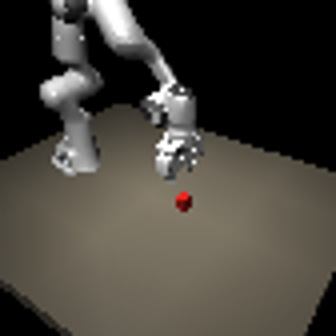

Replay Pixel SAC: 1,024 transitions; CHW=(3,84,84) uint8; images=0.040 GiB; total≈0.041 GiB
Calibrated Pixel SAC: 16.05 training steps/s; 37.28 rendered frames/s
Calibrated Pixel PPO: 20.53 training steps/s; 37.17 rendered frames/s
Replay State SAC: 1,024 transitions; CHW=(3,84,84) uint8; images=0.000 GiB; total≈0.000 GiB
Calibrated State SAC: 44.55 training steps/s; 32.07 rendered frames/s


,train_step_seconds,eval_step_seconds,env_steps_per_second,frames_per_second,updates_per_second,updates_per_second_scope,seconds_per_10000_steps,rss_gib,peak_cuda_gib
Pixel SAC,0.062293,0.044619,16.053075,37.28198,31.203179,isolated optimizer,622.9336,3.075348,0.117105
Pixel PPO,0.048704,0.060108,20.532025,37.166421,0.802032,end-to-end rollout and PPO optimization,487.044019,3.097618,0.117105
State SAC,0.022445,0.015112,44.553056,32.06763,84.622241,isolated optimizer,224.451495,3.097626,0.117105


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Replay Pixel SAC: 512 transitions; CHW=(3,84,84) uint8; images=0.020 GiB; total≈0.020 GiB
pixel_sac_seed991: validation grasp=0.0%, stable=0.0%
pixel_ppo_seed991: validation grasp=0.0%, stable=0.0%
Replay State SAC: 512 transitions; CHW=(3,84,84) uint8; images=0.000 GiB; total≈0.000 GiB
state_sac_seed991: validation grasp=0.0%, stable=0.0%


,agent,seed,status,steps,error
0,Pixel SAC,991,selected,256,None
1,Pixel PPO,991,selected,256,None
2,State SAC,991,selected,256,None


...

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,agent,seed,train_seconds,env_steps,env_steps_per_second,gradient_updates,validation_evaluations,early_stop,stage,training_stability_sd
0,Pixel SAC,991,17.548617,256,14.588044,112,1,False,0,0.0
1,Pixel PPO,991,12.838303,256,19.940330,20,1,False,0,0.0
2,State SAC,991,6.288027,256,40.712296,112,1,False,0,0.0


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Grasp %           Stable Lift %              Return            \
             mean std count          mean std count      mean std count   
Agent                                                                     
Pixel PPO     0.0 NaN     1           0.0 NaN     1 -1.091544 NaN     1   
Pixel SAC     0.0 NaN     1           0.0 NaN     1 -2.366574 NaN     1   
State SAC     0.0 NaN     1           0.0 NaN     1 -2.375183 NaN     1   

          Drop %           Collision %           Train Time (min)            
            mean std count        mean std count             mean std count  
Agent                                                                        
Pixel PPO    0.0 NaN     1         0.0 NaN     1         0.213972 NaN     1  
Pixel SAC    0.0 NaN     1         0.0 NaN     1         0.292477 NaN     1  
State SAC    0.0 NaN     1         0.0 NaN     1         0.104800 NaN     1

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


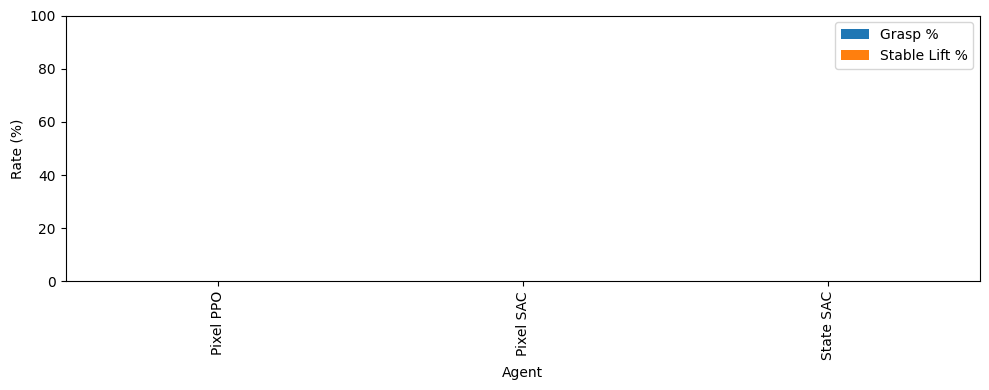

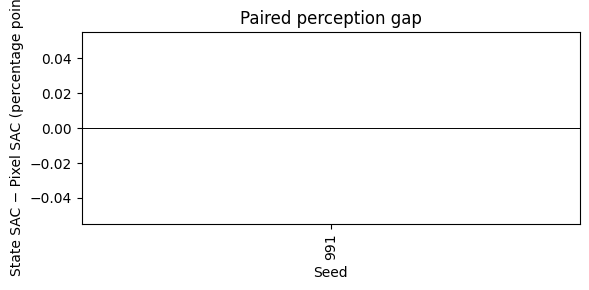

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


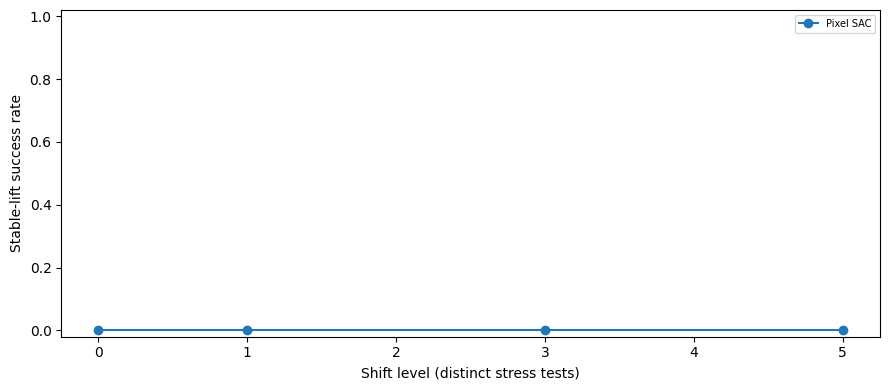

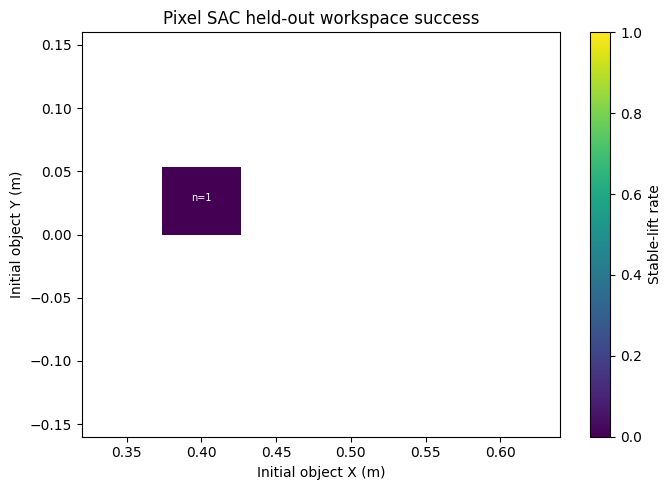

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


failure,failure to approach
agent,
Pixel PPO,1.0
Pixel SAC,1.0
State SAC,1.0


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


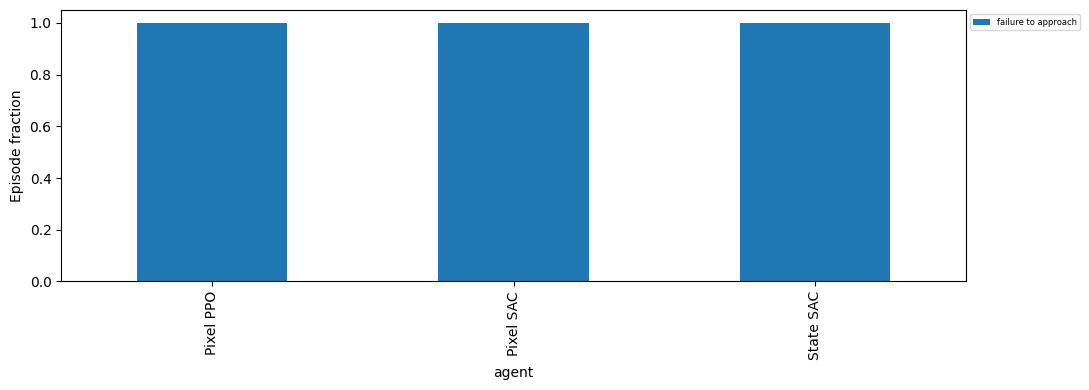

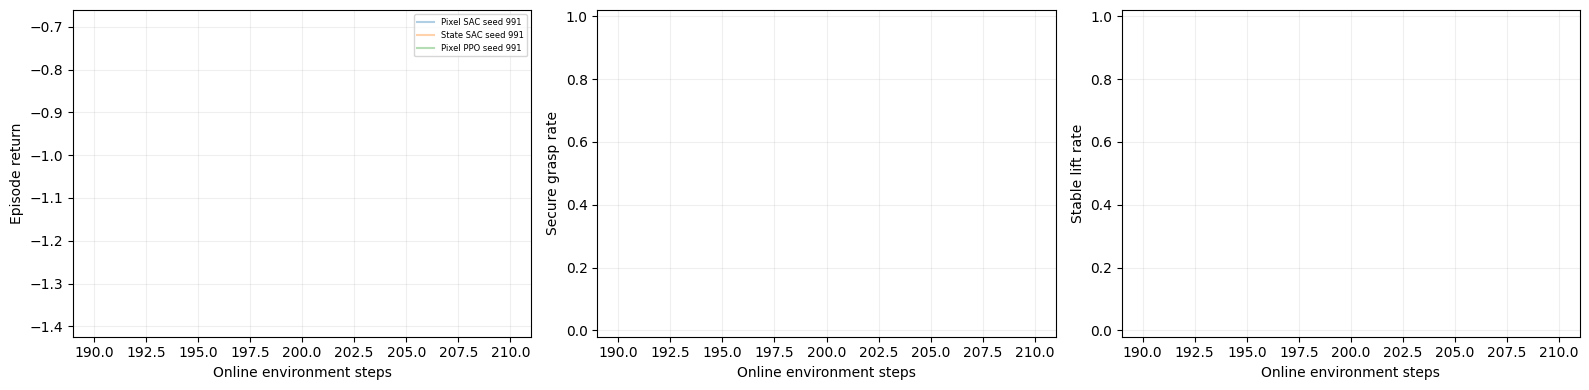

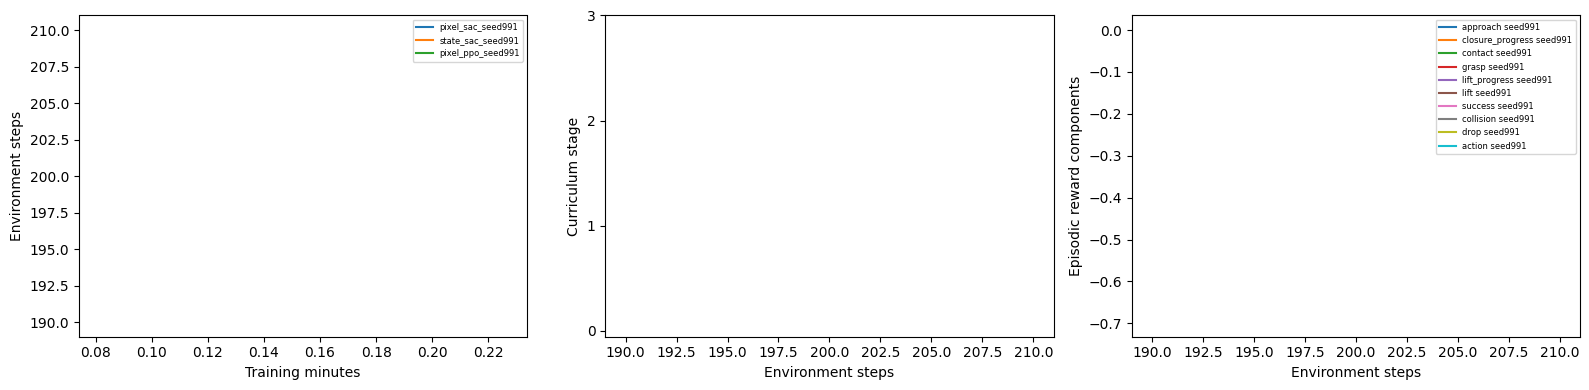

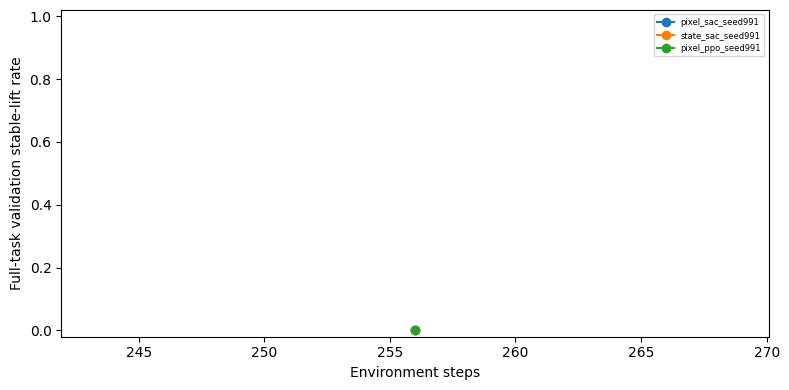

Complete SMOKE pipeline passed. Starting requested experiment.
Planned online training (floors are not convergence guarantees):


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,steps,training_minutes,minimum_steps
Pixel SAC,15193,18.928966,12000
Pixel PPO,3072,2.790644,2048
State SAC,5277,2.369181,4096


Reserved evaluation/reporting: 29.9 minutes
Replay Pixel SAC: 50,000 transitions; CHW=(3,84,84) uint8; images=1.971 GiB; total≈1.979 GiB
pixel_sac_seed11: 2,048 steps, 768 updates, stage 0, recent grasp 0.0%
pixel_sac_seed11: 4,096 steps, 1792 updates, stage 0, recent grasp 15.0%
pixel_sac_seed11: validation grasp=8.3%, stable=0.0%
pixel_sac_seed11: 7,112 steps, 3300 updates, stage 0, recent grasp 25.0%
pixel_sac_seed11: 9,160 steps, 4324 updates, stage 1, recent grasp 40.0%
pixel_sac_seed11: validation grasp=8.3%, stable=0.0%
pixel_sac_seed11: 12,176 steps, 5832 updates, stage 1, recent grasp 40.0%
pixel_sac_seed11: 14,224 steps, 6856 updates, stage 1, recent grasp 55.0%
pixel_sac_seed11: validation grasp=16.7%, stable=0.0%
pixel_sac_seed11: 15,194 steps, 7341 updates, stage 1, recent grasp 55.0%
pixel_sac_seed11: validation grasp=0.0%, stable=0.0%
pixel_ppo_seed11: 2,048 steps, 80 updates, stage 0, recent grasp 10.0%
pixel_ppo_seed11: validation grasp=0.0%, stable=0.0%
Replay State S

In [29]:
EXECUTION_START=time.monotonic()-(INSTALL_SECONDS+IMPORT_SECONDS+ASSET_SECONDS)
sanity_checks(ROOT/"preflight")
display(Image.open(ROOT/"preflight/actual_agent_observation.png").resize((336,336)))
CALIBRATION=calibrate(CFG,ROOT/"configs")
if MODE!="SMOKE":
    smoke_cfg=copy.deepcopy(CFG);smoke_cfg.mode="SMOKE";smoke_cfg.seeds=(991,)
    smoke_cfg.validation_n=1;smoke_cfg.test_n=1;smoke_cfg.shift_n=1;smoke_cfg.levels=(1,3,5)
    smoke_cfg.learning_starts=32;smoke_cfg.batch_size=min(64,CFG.batch_size);smoke_cfg.ppo_rollout=64
    smoke_root=ROOT/"smoke_gate"
    smoke_result=run_experiment(smoke_cfg,smoke_root,CALIBRATION,time.monotonic())
    smoke_table,smoke_costs=generate_reports(smoke_result,smoke_root,smoke_cfg)
    smoke_videos=generate_videos(smoke_result,smoke_root,smoke_cfg)
    assert len(smoke_result["test"])==3 and all(r["complete"] for r in smoke_result["test"]), "SMOKE test pipeline incomplete"
    assert all(r["complete"] for r in smoke_result["shifts"]), "SMOKE generalization pipeline incomplete"
    assert any(v.get("frames",0)>0 for v in smoke_videos), "SMOKE video pipeline failed"
    assert all(s["training"]["gradient_updates"]>0 for s in smoke_result["selections"]), "SMOKE did not optimize every agent"
    print("Complete SMOKE pipeline passed. Starting requested experiment.")
RESULT=run_experiment(CFG,ROOT,CALIBRATION,EXECUTION_START)


,agent,seed,status,steps,error
0,Pixel SAC,11,selected,15194,None
1,Pixel PPO,11,selected,3072,None
2,State SAC,11,selected,5278,None


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### STANDARD — actual executed results

,Agent,Seed,Observation,Grasp %,Stable Lift %,Return,Drop %,Collision %,Timeout %,Steps to Success,Median Time to Grasp (s),Train Time (min),Test Episodes,Complete
0,Pixel SAC,11,RGB + proprioception,4.166667,0.0,0.493537,0.0,0.0,100.0,None,0.8,16.928553,24,True
1,Pixel PPO,11,RGB + proprioception,0.000000,0.0,-1.446346,0.0,0.0,100.0,None,NaN,2.469026,24,True
2,State SAC,11,Privileged state,45.833333,0.0,2.696873,0.0,0.0,100.0,None,0.8,1.972638,24,True


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,agent,seed,train_seconds,env_steps,env_steps_per_second,gradient_updates,validation_evaluations,early_stop,stage,training_stability_sd
0,Pixel SAC,11,1015.713150,15194,14.958948,7341,4,False,1,0.0
1,Pixel PPO,11,148.141566,3072,20.736921,120,1,False,0,0.0
2,State SAC,11,118.358279,5278,44.593416,2383,1,False,0,0.0


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Grasp %           Stable Lift %              Return            \
                mean std count          mean std count      mean std count   
Agent                                                                        
Pixel PPO   0.000000 NaN     1           0.0 NaN     1 -1.446346 NaN     1   
Pixel SAC   4.166667 NaN     1           0.0 NaN     1  0.493537 NaN     1   
State SAC  45.833333 NaN     1           0.0 NaN     1  2.696873 NaN     1   

          Drop %           Collision %           Train Time (min)            
            mean std count        mean std count             mean std count  
Agent                                                                        
Pixel PPO    0.0 NaN     1         0.0 NaN     1         2.469026 NaN     1  
Pixel SAC    0.0 NaN     1         0.0 NaN     1        16.928553 NaN     1  
State SAC    0.0 NaN     1         0.0 NaN     1         1.972638 NaN     1

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


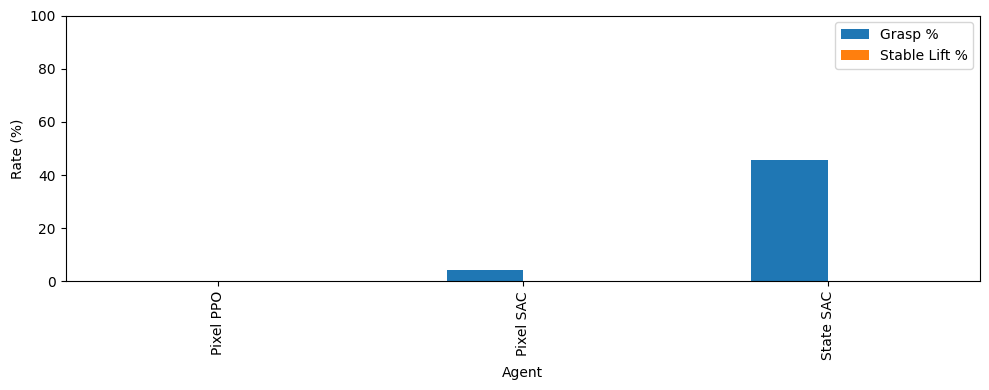

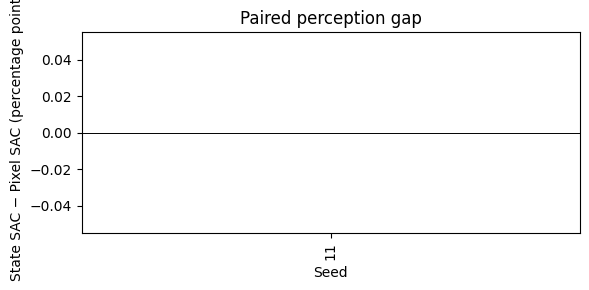

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


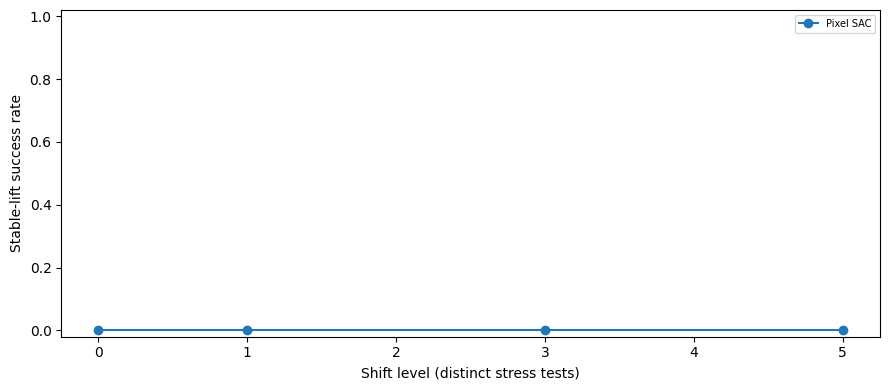

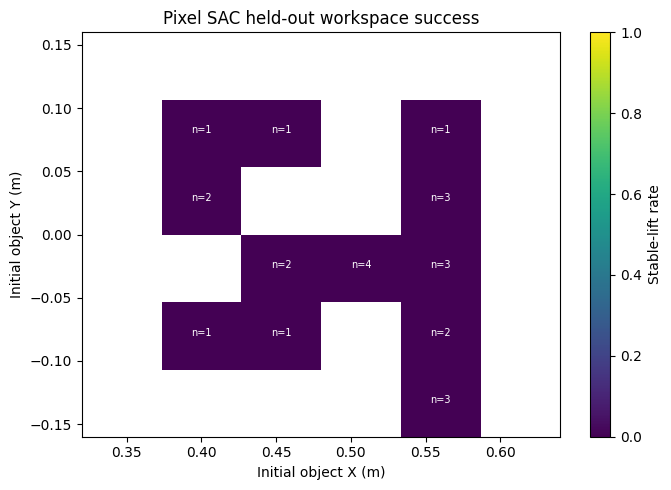

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


failure,failed gripper closure,failure to approach,object pushed away,poor alignment / failed bilateral contact,premature lifting,timeout after grasp
agent,,,,,,
Pixel PPO,0.000000,0.791667,0.125000,0.083333,0.000000,0.000000
Pixel SAC,0.041667,0.458333,0.083333,0.208333,0.166667,0.041667
State SAC,0.000000,0.125000,0.333333,0.333333,0.000000,0.208333


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


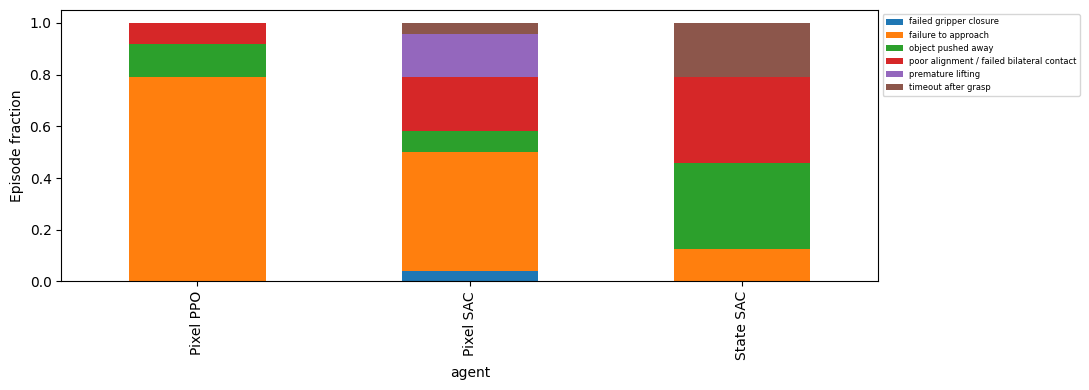

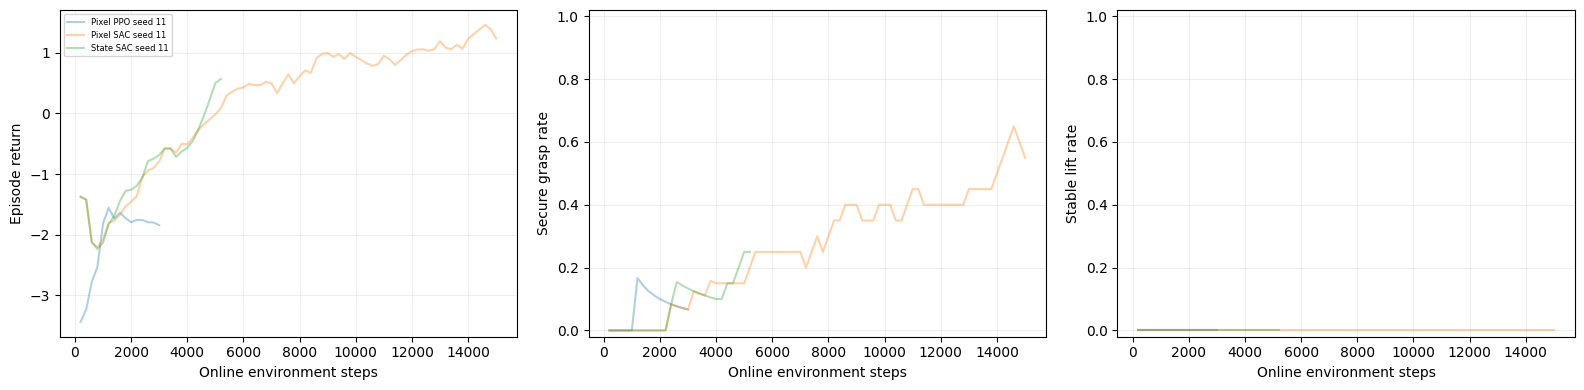

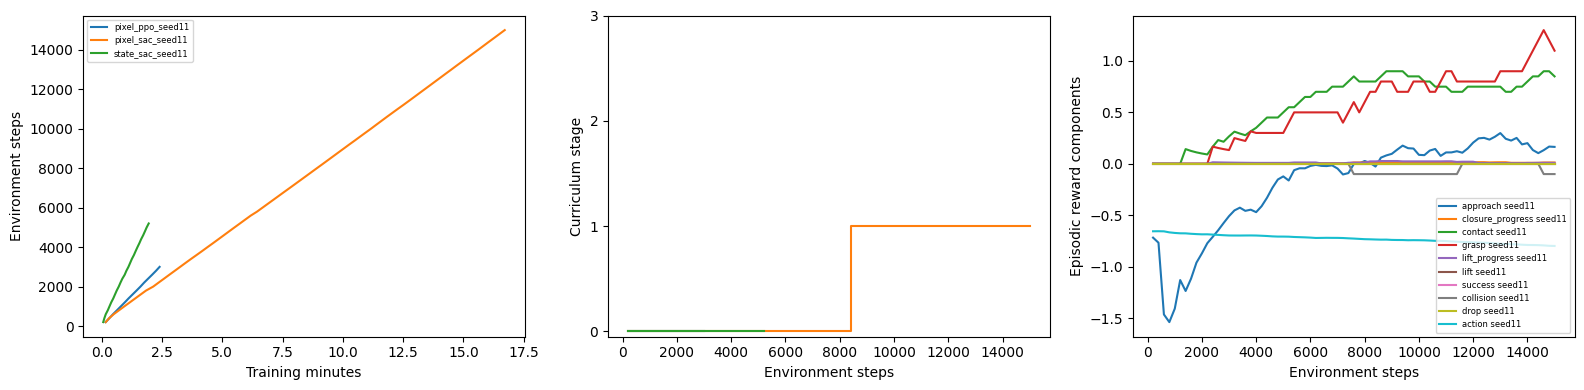

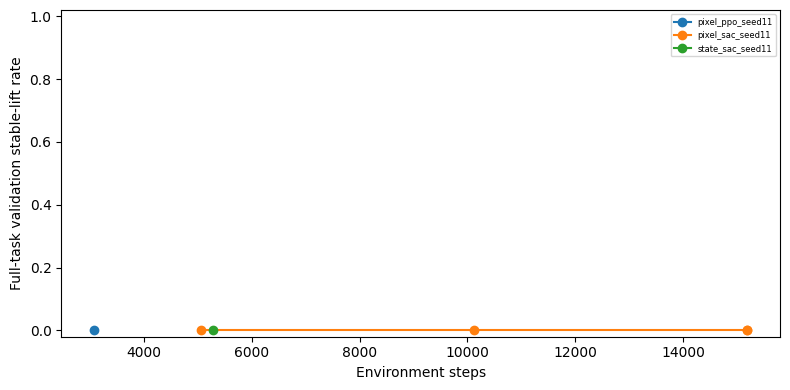

# STANDARD results and interpretation

This execution selected 3/3 planned runs. Elapsed session wall time: 49.44 minutes.

Pixel SAC, seed 11: secure grasp 4.2%, stable lift 0.0%, 24 test episodes; complete bank: True. Training cost 16.93 minutes.

Pixel PPO, seed 11: secure grasp 0.0%, stable lift 0.0%, 24 test episodes; complete bank: True. Training cost 2.47 minutes.

State SAC, seed 11: secure grasp 45.8%, stable lift 0.0%, 24 test episodes; complete bank: True. Training cost 1.97 minutes.

Pixel SAC did not demonstrate a stable lift on this bank; reliable grasping has not been established.

Mean perception gap: 0.0 percentage points (State − Pixel SAC).

Pixel SAC − Pixel PPO stable-lift difference: 0.0 percentage points. Training compute differs.

pixel_sac_seed11: 15,194 online steps, 7,341 optimizer updates, 4 validation evaluations; curriculum transitions: 0→1 at 8000. Early stop: False. Training is not established as converged; the budget or current learning progress is insufficient for that claim.

Validation never reached 50% stable lift in the recorded evaluations.

pixel_ppo_seed11: 3,072 online steps, 120 optimizer updates, 1 validation evaluations; curriculum transitions: none. Early stop: False. Training is not established as converged; the budget or current learning progress is insufficient for that claim.

Validation never reached 50% stable lift in the recorded evaluations.

state_sac_seed11: 5,278 online steps, 2,383 optimizer updates, 1 validation evaluations; curriculum transitions: none. Early stop: False. Training is not established as converged; the budget or current learning progress is insufficient for that claim.

Validation never reached 50% stable lift in the recorded evaluations.

Most frequent classified failure for Pixel PPO: failure to approach (79.2% of all episodes).

Most frequent classified failure for Pixel SAC: failure to approach (45.8% of all episodes).

Most frequent classified failure for State SAC: object pushed away (33.3% of all episodes).

Pixel SAC, generalization level 1: mean stable lift 0.0%; 6 episodes.

Pixel SAC, generalization level 3: mean stable lift 0.0%; 6 episodes.

Pixel SAC, generalization level 5: mean stable lift 0.0%; 6 episodes.

Budgets dynamically reduced: False. Details: [].

Sample/wall-clock efficiency and stability are reported in the compute table and measured validation curves; no extrapolated convergence time is estimated.

Multi-seed comparisons and domain-randomization, proprioception, reward, and curriculum ablations: **Not run in this configuration**.

RGB-D: **Not run in this configuration** (optional extension omitted).


## Reproduction and GitHub-ready project summary
Objective: test end-to-end online vision-based grasping without object pose in pixel policy observations. Environment: MuJoCo Panda, physical parallel fingers, tabletop and randomized primitive objects. Observations: 84×84 RGB plus 16 robot features; RGB-only ablation; privileged 35-dimensional state baseline. Actions: bounded Cartesian XYZ/yaw increments and gripper aperture at 20 Hz. Network: four-convolution CNN (32/64/64/64), 256 latent, two-layer actor/critic heads. Algorithms: SAC with twin targets and learned entropy; PPO with GAE/clipped objective. Reward: progress, one-shot physical milestones, action/collision/drop penalties. Protocol: procedural online training, fixed disjoint validation/test seeds, validation-only checkpoint selection, fixed shifted banks. Results: the actual tables and figures in results/ and figures/; generalization and failure reports accompany representative videos. Reproduce: open this notebook in Colab, choose SMOKE/STANDARD/FULL, optionally mount Drive, and Run all. Keep the same experiment name and configuration to resume; use a new name for changed hyperparameters. FULL remains incomplete until all 21 runs and their banks are complete. STANDARD is one-seed evidence with a constrained compute budget.

Total wall-clock runtime: 49.44 minutes
Cumulative completed-session wall time: 0.82 hours (abruptly killed sessions may be undercounted)
Held-out test episodes: 72 Generalization episodes: 18
{'category': 'successful_grasp', 'status': "No qualifying episode in the illustrated seed's bank", 'training_seed': 11}
{'category': 'unseen_geometry', 'status': 'Not run in this configuration'}


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


failed_grasp

difficult_start

unseen_appearance

camera_shift

All experiment artifacts: /content/panda_pixels_v2/standard


In [30]:
REPORT_STARTED=time.monotonic()
COMPARISON,COMPUTE=generate_reports(RESULT,ROOT,CFG)
VIDEOS=generate_videos(RESULT,ROOT,CFG)
RESULT["total_wall_seconds_including_reports"]=RESULT["wall_seconds"]+time.monotonic()-REPORT_STARTED
SESSION_HISTORY=read_json(ROOT/"results/sessions.json",[])
SESSION_HISTORY.append(dict(finished_unix=time.time(),mode=MODE,wall_seconds=RESULT["total_wall_seconds_including_reports"]))
write_json(ROOT/"results/sessions.json",SESSION_HISTORY)
RESULT["cumulative_recorded_wall_seconds"]=sum(s["wall_seconds"] for s in SESSION_HISTORY)
RESULT["held_out_test_episodes"]=sum(r.get("episodes",0) for r in RESULT["test"])
RESULT["generalization_episodes"]=sum(r.get("episodes",0) for r in RESULT["shifts"])
write_json(ROOT/"results/experiment.json",RESULT)
SUMMARY=interpretation(RESULT,COMPARISON,COMPUTE,ROOT,CFG)
print(f"Total wall-clock runtime: {RESULT['total_wall_seconds_including_reports']/60:.2f} minutes")
print(f"Cumulative completed-session wall time: {RESULT['cumulative_recorded_wall_seconds']/3600:.2f} hours (abruptly killed sessions may be undercounted)")
print("Held-out test episodes:",RESULT["held_out_test_episodes"],"Generalization episodes:",RESULT["generalization_episodes"])
for video in VIDEOS:
    if video.get("frames",0):display(Markdown(video["category"]));display(Video(video["path"],embed=True,width=784))
    else:print(video)
print("All experiment artifacts:",ROOT)


## Local verification of this revision (before the Colab rerun)
CPU preflight and the complete three-agent SMOKE pipeline passed, including checkpoints, reports, and videos.
A separate 12,000-step State SAC probe (seed 887) recorded 19 grasp episodes among 60 training episodes,
53 approach episodes, and curriculum stage 1, but zero stable lifts. This is privileged-state exploratory training,
not a held-out test and not evidence of pixel-policy success. No probe weights or transitions are reused here.
The 256-step SMOKE agents had zero held-out grasps. A full STANDARD run of this revision remains to be evaluated.

## Limitations and conclusion
* Simulation is not a real robot. No physical-robot validation or deployment capability is claimed.
* The fixed external camera can hide contact and depth; a single RGB frame is partially observable.
* Cartesian IK simplifies the control problem and restricts roll/pitch; action-target history is not fully observed.
* Objects are simple primitives. Appearance shifts use colors/material appearance, not a diverse texture dataset.
* Dense shaping and curriculum can materially affect learning; FULL includes controlled ablations for both.
* MuJoCo's rigid contacts, friction, and idealized actuators differ from hardware, tactile sensing, and deformable objects.
* Pixel RL is compute-intensive. STANDARD may collect too little online experience and has only one seed; failure to converge is plausible.
* Different training-time allocations confound raw algorithm ranking; read sample and wall-clock curves together.
* Replay omission makes resumed optimization history differ from uninterrupted training. Resumption is safe but not bitwise identical.
* Small evaluation banks, finite object diversity, and correlated fixed configurations limit statistical generalization claims.

The central question is answered only by the executed validation/test/shift results above. Software success is distinct from learned
grasping success. Preserve negative results and incomplete-run labels in a portfolio write-up.

## References and implementation provenance
- [MuJoCo Python API and rendering](https://mujoco.readthedocs.io/en/stable/python.html)
- [MuJoCo Menagerie Panda assets and license](https://github.com/google-deepmind/mujoco_menagerie/tree/822c2d8f877dd166c5b7d3c9f7e3c3b6589473b7/franka_emika_panda)
- [Stable-Baselines3 SAC documentation](https://stable-baselines3.readthedocs.io/en/v2.7.0/modules/sac.html)
- [Stable-Baselines3 PPO documentation](https://stable-baselines3.readthedocs.io/en/v2.7.0/modules/ppo.html)
- [Soft Actor-Critic](https://arxiv.org/abs/1801.01290), Haarnoja et al., 2018
- [Proximal Policy Optimization](https://arxiv.org/abs/1707.06347), Schulman et al., 2017

The notebook's environment, controller integration, observation tests, experiment protocol, budgeting, and reporting are custom;
SAC/PPO optimization and replay implementations are supplied by Stable-Baselines3. Cite both when publishing results.
